# 🚗 Vehicle Sales — Exploratory Data Analysis
### Kaggle Dataset: [Vehicle Sales Data](https://www.kaggle.com/datasets/syedanwarafridi/vehicle-sales-data)

---

## 📌 Project Overview

This notebook presents a complete end-to-end Exploratory Data Analysis (EDA) of a real-world vehicle auction dataset containing **558,837 records** across 16 features — covering make, model, condition, odometer, selling price, MMR market value, sale date, and geographic data across **38 US states and Canadian provinces**.

The analysis follows the full analyst workflow: data loading → cleaning → outlier detection → feature engineering → univariate analysis → bivariate analysis → business question-driven deep dives.

---

## 📊 Dataset at a Glance

| Attribute | Value |
|---|---|
| Raw records | 558,837 |
| Records after cleaning | 534,177 |
| Features | 16 (+ 6 engineered) |
| Sale years | 2014 – 2015 |
| States / Provinces | 38 |
| Unique makes | 40+ |
| Price range | $1 – $35,100 |

---

## 🔑 5 Key Findings

> **1. MMR is a near-perfect price proxy (r = 0.978, r² = 0.956)**  
> The Manheim Market Report explains 95.6% of selling price variance — confirming it as the dominant benchmark. Excluding MMR, vehicle age (r = −0.655) and odometer (r = −0.642) are the strongest real predictors.

> **2. The 50,000-mile depreciation cliff**  
> Mileage reduces price by ~$933 per 10,000 miles on average — but the relationship is non-linear. Prices drop only 9.5% from 0–20K to 20–50K miles, then collapse 31.4% at the 50K threshold. Total erosion from low to high mileage reaches 86.4%.

> **3. 53.3% of vehicles sell above MMR — but losses hurt more than gains**
> The market leans slightly above benchmark (avg premium +$948), but below-MMR vehicles lose an average of −$1,140 — a 20% asymmetry. A long left tail stretching to −$80,000 is driven by luxury makes like Bentley and Porsche.

> **4. Florida leads revenue ($1.02B) but not price quality**
> FL dominates by volume (79,404 units) but its avg price ($12,861) is near the fleet average. Pennsylvania and Tennessee are the true dual-strength markets — ranking top 4 in both revenue and avg price simultaneously.

> **5. Ford dominates volume but not premium pricing**  
> Ford places 4 models in the top 10 by volume (48,319 combined units), yet only the F-150 ($17,905) beats the fleet average. All 10 best-selling models sell below their MMR benchmark — confirming that high auction volume creates buyer pricing power.

---

## 🗂️ Notebook Structure

| Section | Questions Covered |
|---|---|
| Data Loading & Inspection | Shape, dtypes, duplicates, null counts |
| Null Handling | Mean / median / mode strategy per column |
| Outlier Detection | IQR method + Z-score comparison |
| Feature Engineering | vehicle_age, sale_month, quarter, price_vs_market, mileage_bucket |
| Univariate Analysis | Price distribution, volume by category, condition spread |
| Bivariate Analysis | Odometer vs price, correlation heatmap, avg price by make |
| 💰 Pricing Analysis | Q01 · Q02 · Q03 |
| 🚗 Vehicle Characteristics | Q05 · Q08 |
| 📅 Sales Trends Over Time | Q09 |
| 🗺️ Regional & Seller Analysis | Q13 |
| 🔗 Correlation & Multivariate | Q17 |
| 🏆 Make & Model Deep Dive | Q21 |

---

*Python 3 · pandas · numpy · matplotlib · seaborn · scipy*

## Load Libraries

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Load & Inspect

In [4]:
df = pd.read_csv("car_prices.csv")

In [29]:
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [30]:
df.describe()

,year,condition,odometer,mmr,sellingprice
count,558837.000000,547017.000000,558743.000000,558799.000000,558825.000000
mean,2010.038927,30.672365,68320.017767,13769.377495,13611.358810
std,3.966864,13.402832,53398.542821,9679.967174,9749.501628
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,23.000000,28371.000000,7100.000000,6900.000000
50%,2012.000000,35.000000,52254.000000,12250.000000,12100.000000
75%,2013.000000,42.000000,99109.000000,18300.000000,18200.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [5]:
df['vin'].duplicated().sum()

np.int64(8539)

In [51]:
df.shape

(558837, 16)

In [6]:
df = df.drop_duplicates(subset=['vin'], keep='last')

In [53]:
df.shape

(550298, 16)

## Handle Nulls

In [35]:
df.isnull().sum()

year                0
make            10167
model           10265
trim            10501
body            12988
transmission    64272
vin                 1
state               0
condition       11506
odometer           83
color             727
interior          727
seller              0
mmr                14
sellingprice       12
saledate           12
dtype: int64

In [36]:
nulls = (df.isnull().sum()/len(df))*100
nulls

year             0.000000
make             1.847544
model            1.865353
trim             1.908239
body             2.360176
transmission    11.679490
vin              0.000182
state            0.000000
condition        2.090867
odometer         0.015083
color            0.132110
interior         0.132110
seller           0.000000
mmr              0.002544
sellingprice     0.002181
saledate         0.002181
dtype: float64

In [7]:
# --- Check distribution before deciding ---
print(df['odometer'].describe())       # look at mean vs 50% (median)
print(df['condition'].describe())
print(df['body'].value_counts().head()) # see what mode actually is

# 1. Drop rows where critical numeric columns are null
df.dropna(subset=['sellingprice', 'saledate', 'mmr'], inplace=True)

# --- Numeric: use MEDIAN (safe for skewed data) ---
df['odometer'].fillna(df['odometer'].median(), inplace=True)
df['condition'].fillna(df['condition'].median(), inplace=True)
df['mmr'].fillna(df['mmr'].median(), inplace=True)

# --- Categorical: use MODE ---
df['body'].fillna(df['body'].mode()[0], inplace=True)
df['color'].fillna(df['color'].mode()[0], inplace=True)
df['interior'].fillna(df['interior'].mode()[0], inplace=True)

# --- High-null categoricals: use "Unknown" to avoid bias ---
df['transmission'].fillna('Unknown', inplace=True)
df['make'].fillna('Unknown', inplace=True)
df['model'].fillna('Unknown', inplace=True)
df['trim'].fillna('Unknown', inplace=True)

count    550215.000000
mean      68325.463023
std       53543.860425
min           1.000000
25%       28287.000000
50%       52091.000000
75%       99235.500000
max      999999.000000
Name: odometer, dtype: float64
count    538792.000000
mean         30.693928
std          13.408302
min           1.000000
25%          23.000000
50%          35.000000
75%          42.000000
max          49.000000
Name: condition, dtype: float64
body
Sedan      196555
SUV        116884
sedan       41789
suv         24454
Minivan     21057
Name: count, dtype: int64


In [8]:
df.isnull().sum()

year            0
make            0
model           0
trim            0
body            0
transmission    0
vin             0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
mmr             0
sellingprice    0
saledate        0
dtype: int64

## Outlier Detection

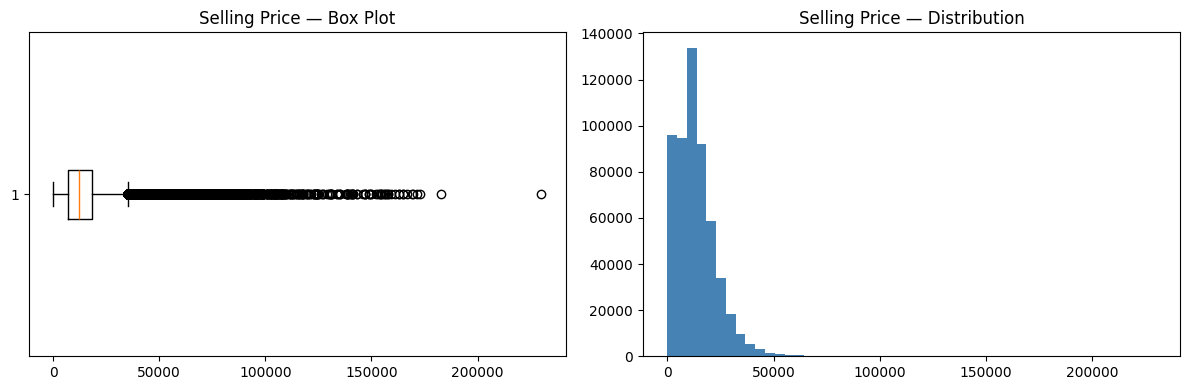

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box plot — shows outlier dots clearly
axes[0].boxplot(df['sellingprice'].dropna(), vert=False)
axes[0].set_title('Selling Price — Box Plot')

# Histogram — shows distribution shape
axes[1].hist(df['sellingprice'].dropna(), bins=50, color='steelblue')
axes[1].set_title('Selling Price — Distribution')

plt.tight_layout()
plt.savefig('outliers.png', dpi=150, bbox_inches='tight')
plt.show()

### IQR 

In [10]:
# IQR method on sellingprice
Q1 = df['sellingprice'].quantile(0.25)
Q3 = df['sellingprice'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['sellingprice'] < lower) | (df['sellingprice'] > upper)]
print(f"Outliers found: {len(outliers):,}")

# Remove outliers
df = df[(df['sellingprice'] >= lower) & (df['sellingprice'] <= upper)]

Outliers found: 16,107


In [11]:
# Detect outliers across all key numeric columns
numeric_cols = ['sellingprice', 'mmr', 'odometer', 'condition']
mask = pd.Series([True] * len(df), index=df.index) # Start with all True mask

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    pct = count / len(df) * 100
    print(f"{col:15s} → lower: {lower:,.0f}  upper: {upper:,.0f}  outliers: {count:,} ({pct:.1f}%)")
    # Create a mask for the current column, keeping values within bounds
    col_mask = (df[col] >= lower) & (df[col] <= upper)
    # Combine masks: a row is kept only if it's not an outlier in *any* column
    mask = mask & col_mask

# Filter the original DataFrame using the combined mask
df_c = df[mask]

print(f"Original DataFrame shape: {df.shape}")
print(f"Filtered DataFrame shape (outliers removed): {df_c.shape}")

sellingprice    → lower: -9,750  upper: 33,850  outliers: 2,747 (0.5%)
mmr             → lower: -9,138  upper: 33,562  outliers: 3,878 (0.7%)
odometer        → lower: -77,939  upper: 208,069  outliers: 9,502 (1.8%)
condition       → lower: -2  upper: 66  outliers: 0 (0.0%)
Original DataFrame shape: (534177, 16)
Filtered DataFrame shape (outliers removed): (519875, 16)


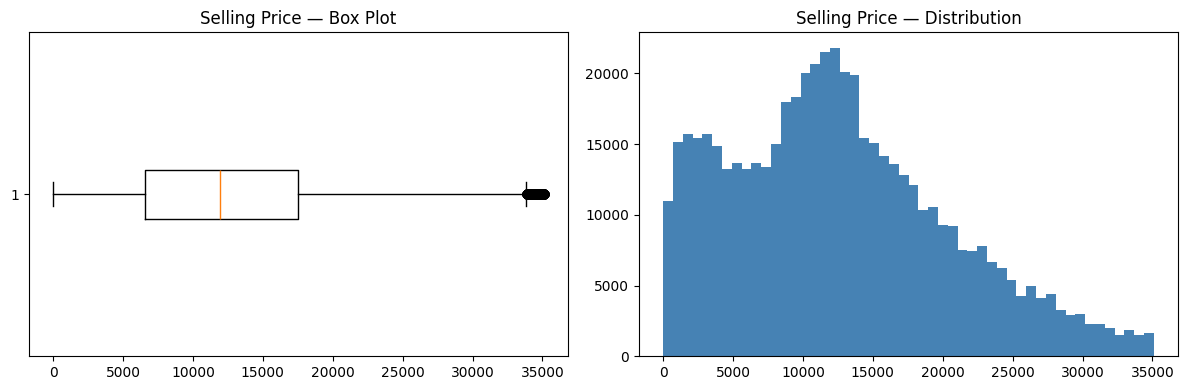

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box plot — shows outlier dots clearly
axes[0].boxplot(df['sellingprice'].dropna(), vert=False)
axes[0].set_title('Selling Price — Box Plot')

# Histogram — shows distribution shape
axes[1].hist(df['sellingprice'].dropna(), bins=50, color='steelblue')
axes[1].set_title('Selling Price — Distribution')

plt.tight_layout()
plt.show()

### Z Score

In [57]:
from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(df['sellingprice'].dropna()))
outliers_z = df[z_scores > 3]
print(f"Outliers found: {len(outliers_z):,}")

# Remove
df_clean = df[z_scores <= 3]

Outliers found: 6,859


## Feature Engineering

In [13]:
df['saledate'].values

array(['Tue Dec 16 2014 12:30:00 GMT-0800 (PST)',
       'Tue Dec 16 2014 12:30:00 GMT-0800 (PST)',
       'Thu Jan 15 2015 04:30:00 GMT-0800 (PST)', ...,
       'Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)',
       'Thu Jul 09 2015 06:45:00 GMT-0700 (PDT)',
       'Thu May 28 2015 05:30:00 GMT-0700 (PDT)'],
      shape=(534177,), dtype=object)

In [14]:
# Parse saledate
df['saledate'] = pd.to_datetime(df['saledate'], utc=True)

# Extract time features
df['sale_time'] = df['saledate'].dt.time
df['sale_year']  = df['saledate'].dt.year
df['sale_month'] = df['saledate'].dt.month
df['sale_month_name'] = df['saledate'].dt.strftime('%b')
df['quarter']    = df['saledate'].dt.quarter.map({1:'Q1',2:'Q2',3:'Q3',4:'Q4'})
df['day_of_week'] = df['saledate'].dt.day_name()

# Vehicle age at time of sale
df['vehicle_age'] = df['sale_year'] - df['year']

# Price vs market (key KPI unique to this dataset)
df['price_vs_market'] = df['sellingprice'] - df['mmr']
df['price_vs_market_pct'] = ((df['sellingprice'] - df['mmr']) / df['mmr'] * 100).round(2)

# Mileage bucket (useful for grouping)
df['mileage_bucket'] = pd.cut(df['odometer'],
    bins=[0, 20000, 50000, 100000, 150000, 999999],
    labels=['0–20K', '20–50K', '50–100K', '100–150K', '150K+'])

print(df[['saledate','sale_time','sale_year','sale_month','quarter',
          'vehicle_age','price_vs_market','mileage_bucket']].head())

                   saledate sale_time  sale_year  sale_month quarter  \
0 2014-12-16 04:30:00+00:00  04:30:00       2014          12      Q4   
1 2014-12-16 04:30:00+00:00  04:30:00       2014          12      Q4   
2 2015-01-14 20:30:00+00:00  20:30:00       2015           1      Q1   
3 2015-01-28 20:30:00+00:00  20:30:00       2015           1      Q1   
5 2014-12-30 04:00:00+00:00  04:00:00       2014          12      Q4   

   vehicle_age  price_vs_market mileage_bucket  
0           -1           1000.0          0–20K  
1           -1            700.0          0–20K  
2            1          -1900.0          0–20K  
3            0            250.0          0–20K  
5           -1          -4450.0          0–20K  


## Univariate Analysis

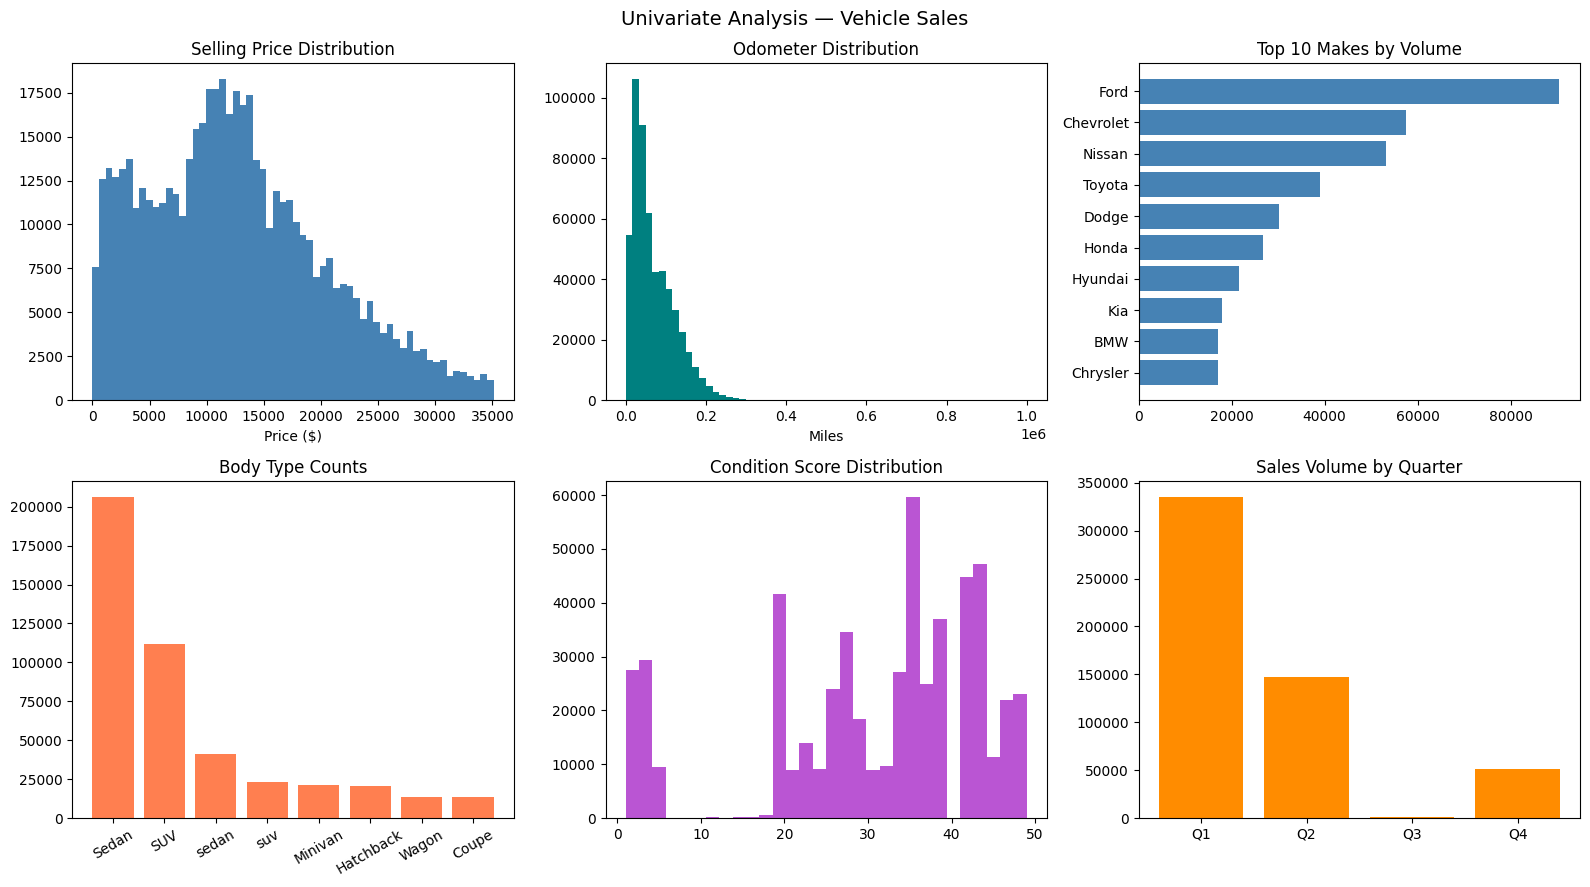

       sellingprice        mmr   odometer  condition  vehicle_age
count     534177.00  534177.00  534177.00  534177.00    534177.00
mean       12642.82   12807.89   69664.84      30.62         4.95
std         7773.13    7721.99   53695.42      13.20         3.97
min            1.00      25.00       1.00       1.00        -1.00
25%         6600.00    6875.00   29314.00      24.00         2.00
50%        11900.00   12000.00   53740.00      35.00         3.00
75%        17500.00   17550.00  100816.00      41.00         8.00
max        35100.00  110000.00  999999.00      49.00        33.00


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Univariate Analysis — Vehicle Sales', fontsize=14)

# 1. Selling price distribution
axes[0,0].hist(df['sellingprice'], bins=60, color='steelblue', edgecolor='none')
axes[0,0].set_title('Selling Price Distribution')
axes[0,0].set_xlabel('Price ($)')

# 2. Odometer distribution
axes[0,1].hist(df['odometer'], bins=60, color='teal', edgecolor='none')
axes[0,1].set_title('Odometer Distribution')
axes[0,1].set_xlabel('Miles')

# 3. Top 10 makes by volume
top_makes = df['make'].value_counts().head(10)
axes[0,2].barh(top_makes.index[::-1], top_makes.values[::-1], color='steelblue')
axes[0,2].set_title('Top 10 Makes by Volume')

# 4. Body type breakdown
body_counts = df['body'].value_counts().head(8)
axes[1,0].bar(body_counts.index, body_counts.values, color='coral')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].set_title('Body Type Counts')

# 5. Condition score distribution
axes[1,1].hist(df['condition'], bins=30, color='mediumorchid', edgecolor='none')
axes[1,1].set_title('Condition Score Distribution')

# 6. Sales by quarter
q_counts = df['quarter'].value_counts().sort_index()
axes[1,2].bar(q_counts.index, q_counts.values, color='darkorange')
axes[1,2].set_title('Sales Volume by Quarter')

plt.tight_layout()
plt.savefig('Univariate_Analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Key summary stats
print(df[['sellingprice','mmr','odometer','condition','vehicle_age']].describe().round(2))

## Bivariate & Correlation Analysis

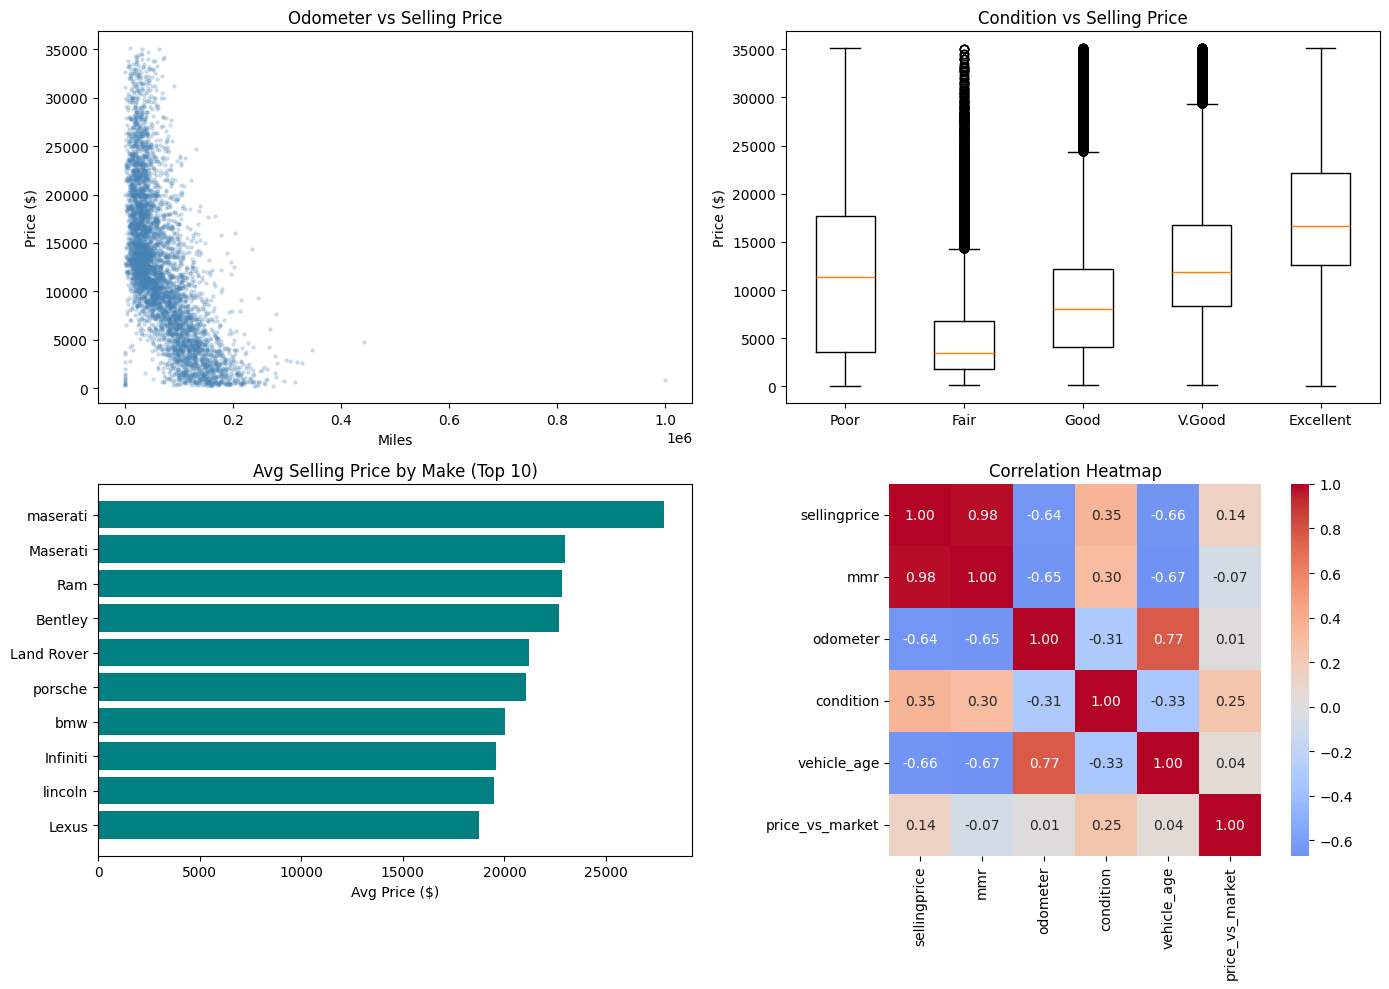

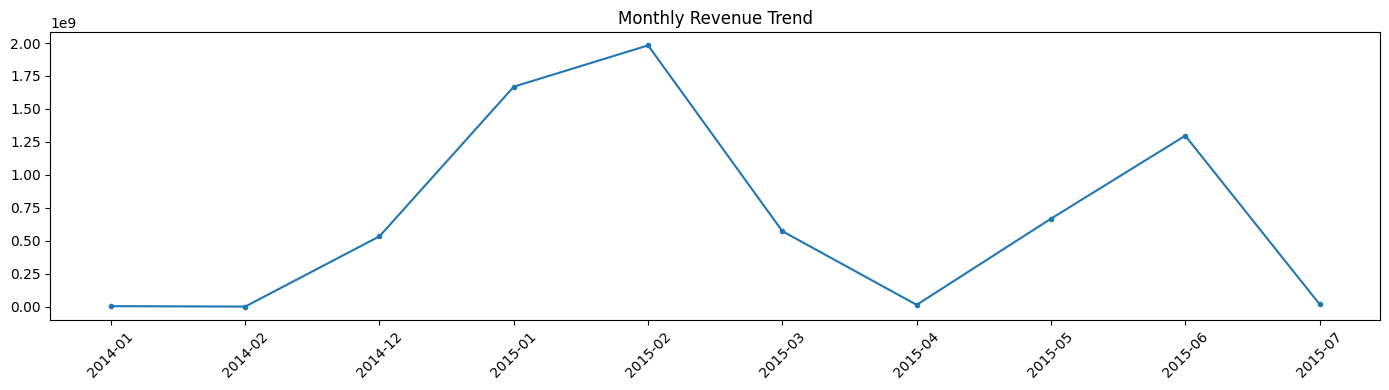

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Odometer vs Selling Price (scatter)
sample = df.sample(5000, random_state=42)  # sample for speed
axes[0,0].scatter(sample['odometer'], sample['sellingprice'],
                  alpha=0.2, s=5, color='steelblue')
axes[0,0].set_title('Odometer vs Selling Price')
axes[0,0].set_xlabel('Miles'); axes[0,0].set_ylabel('Price ($)')

# 2. Condition vs Selling Price (box plot by condition bucket)
df['cond_bucket'] = pd.cut(df['condition'], bins=5,
                           labels=['Poor','Fair','Good','Very Good','Excellent'])
cond_groups = [grp['sellingprice'].values for _, grp in df.groupby('cond_bucket')]
axes[0,1].boxplot(cond_groups, labels=['Poor','Fair','Good','V.Good','Excellent'])
axes[0,1].set_title('Condition vs Selling Price')
axes[0,1].set_ylabel('Price ($)')

# 3. Avg selling price by top 10 makes
avg_by_make = df.groupby('make')['sellingprice'].mean().sort_values(ascending=False).head(10)
axes[1,0].barh(avg_by_make.index[::-1], avg_by_make.values[::-1], color='teal')
axes[1,0].set_title('Avg Selling Price by Make (Top 10)')
axes[1,0].set_xlabel('Avg Price ($)')

# 4. Correlation heatmap (numeric columns only)
corr_cols = ['sellingprice','mmr','odometer','condition','vehicle_age','price_vs_market']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1,1], square=True)
axes[1,1].set_title('Correlation Heatmap')

plt.savefig('Bivariate_&_Correlation_Analysis.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

# Monthly revenue trend
monthly_rev = df.groupby(['sale_year','sale_month'])['sellingprice'].sum().reset_index()
monthly_rev['period'] = monthly_rev['sale_year'].astype(str) + '-' + \
                        monthly_rev['sale_month'].astype(str).str.zfill(2)
plt.figure(figsize=(14, 4))
plt.plot(monthly_rev['period'], monthly_rev['sellingprice'], marker='o', ms=3)
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.tight_layout()
plt.savefig('Monthly_Revenue_Trend.png', dpi=150, bbox_inches='tight')
plt.show()

## 💰 Pricing Analysis

### Q01 — Selling Price Distribution

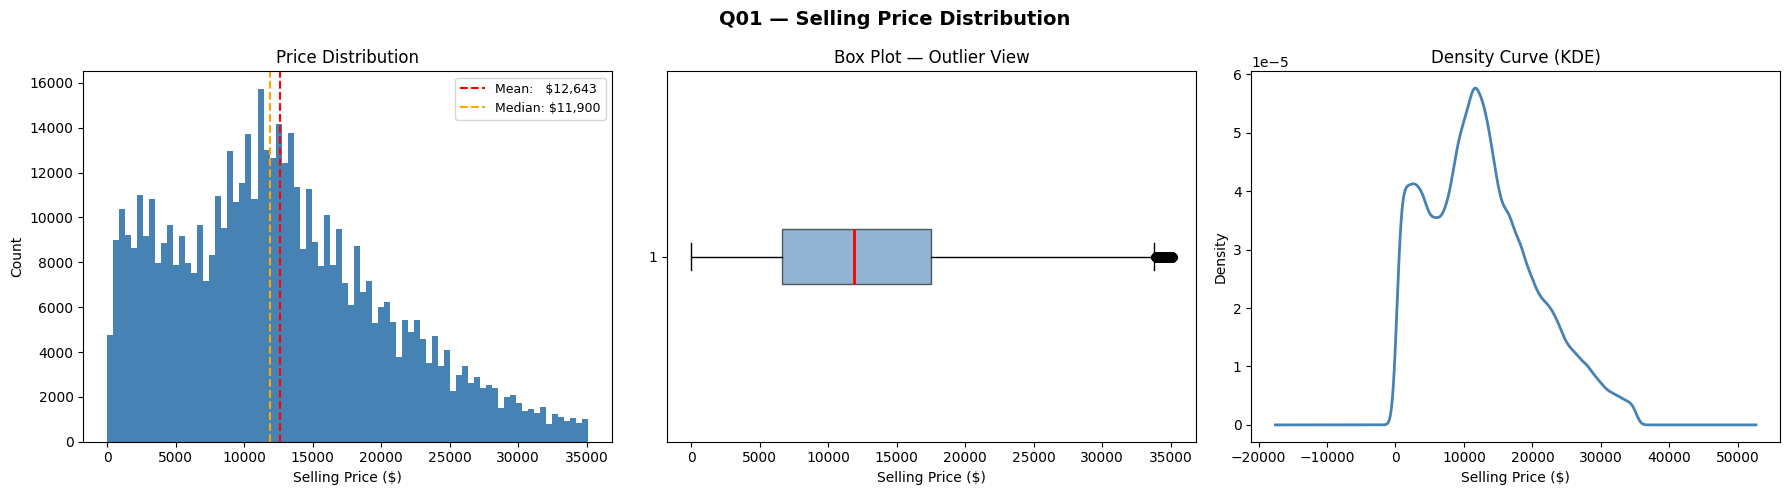


--- Q01 Summary ---
count    $534,177.00
mean      $12,642.82
std        $7,773.13
min            $1.00
25%        $6,600.00
50%       $11,900.00
75%       $17,500.00
max       $35,100.00
Name: sellingprice, dtype: object

Skewness : 0.526  (right-skewed — luxury outliers pulling mean up)
Kurtosis : -0.263
% under $20K  : 82.0%
% $20K–$50K   : 18.0%
% over  $50K  : 0.0%


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Q01 — Selling Price Distribution', fontsize=14, fontweight='bold')

# Histogram
axes[0].hist(df['sellingprice'].dropna(), bins=80, color='steelblue', edgecolor='none')
axes[0].axvline(df['sellingprice'].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f"Mean:   ${df['sellingprice'].mean():,.0f}")
axes[0].axvline(df['sellingprice'].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Median: ${df['sellingprice'].median():,.0f}")
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Selling Price ($)')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)

# Box plot (to see outliers clearly)
axes[1].boxplot(df['sellingprice'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Box Plot — Outlier View')
axes[1].set_xlabel('Selling Price ($)')

# KDE (smooth density curve)
df['sellingprice'].dropna().plot(kind='kde', ax=axes[2], color='steelblue', linewidth=2)
axes[2].set_title('Density Curve (KDE)')
axes[2].set_xlabel('Selling Price ($)')
axes[2].set_ylabel('Density')

plt.tight_layout()
plt.savefig('Selling_Price_Distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Key stats
skewness = df['sellingprice'].skew()
kurt     = df['sellingprice'].kurt()
print(f"\n--- Q01 Summary ---")
print(df['sellingprice'].describe().apply(lambda x: f"${x:,.2f}"))
print(f"\nSkewness : {skewness:.3f}  {'(right-skewed — luxury outliers pulling mean up)' if skewness > 0.5 else '(roughly symmetric)'}")
print(f"Kurtosis : {kurt:.3f}")
print(f"% under $20K  : {(df['sellingprice'] < 20000).mean()*100:.1f}%")
print(f"% $20K–$50K   : {((df['sellingprice'] >= 20000) & (df['sellingprice'] < 50000)).mean()*100:.1f}%")
print(f"% over  $50K  : {(df['sellingprice'] > 50000).mean()*100:.1f}%")

#### Observations:

• The vehicle selling price distribution is moderately right-skewed (skewness = **0.526**) with a median of **$11,900**, indicating that **82%** of sales are below **$20,000**, whereas a small tail of luxury vehicles inflates the mean to **$12,643**.

• The KDE curve reveals a bimodal pattern, suggesting two distinct market segments: economy and near-new certified vehicles, and the **$1** minimum indicates the presence of residual dirty data that requires removal.

### Q02 — Which Makes Sell Above or Below MMR?

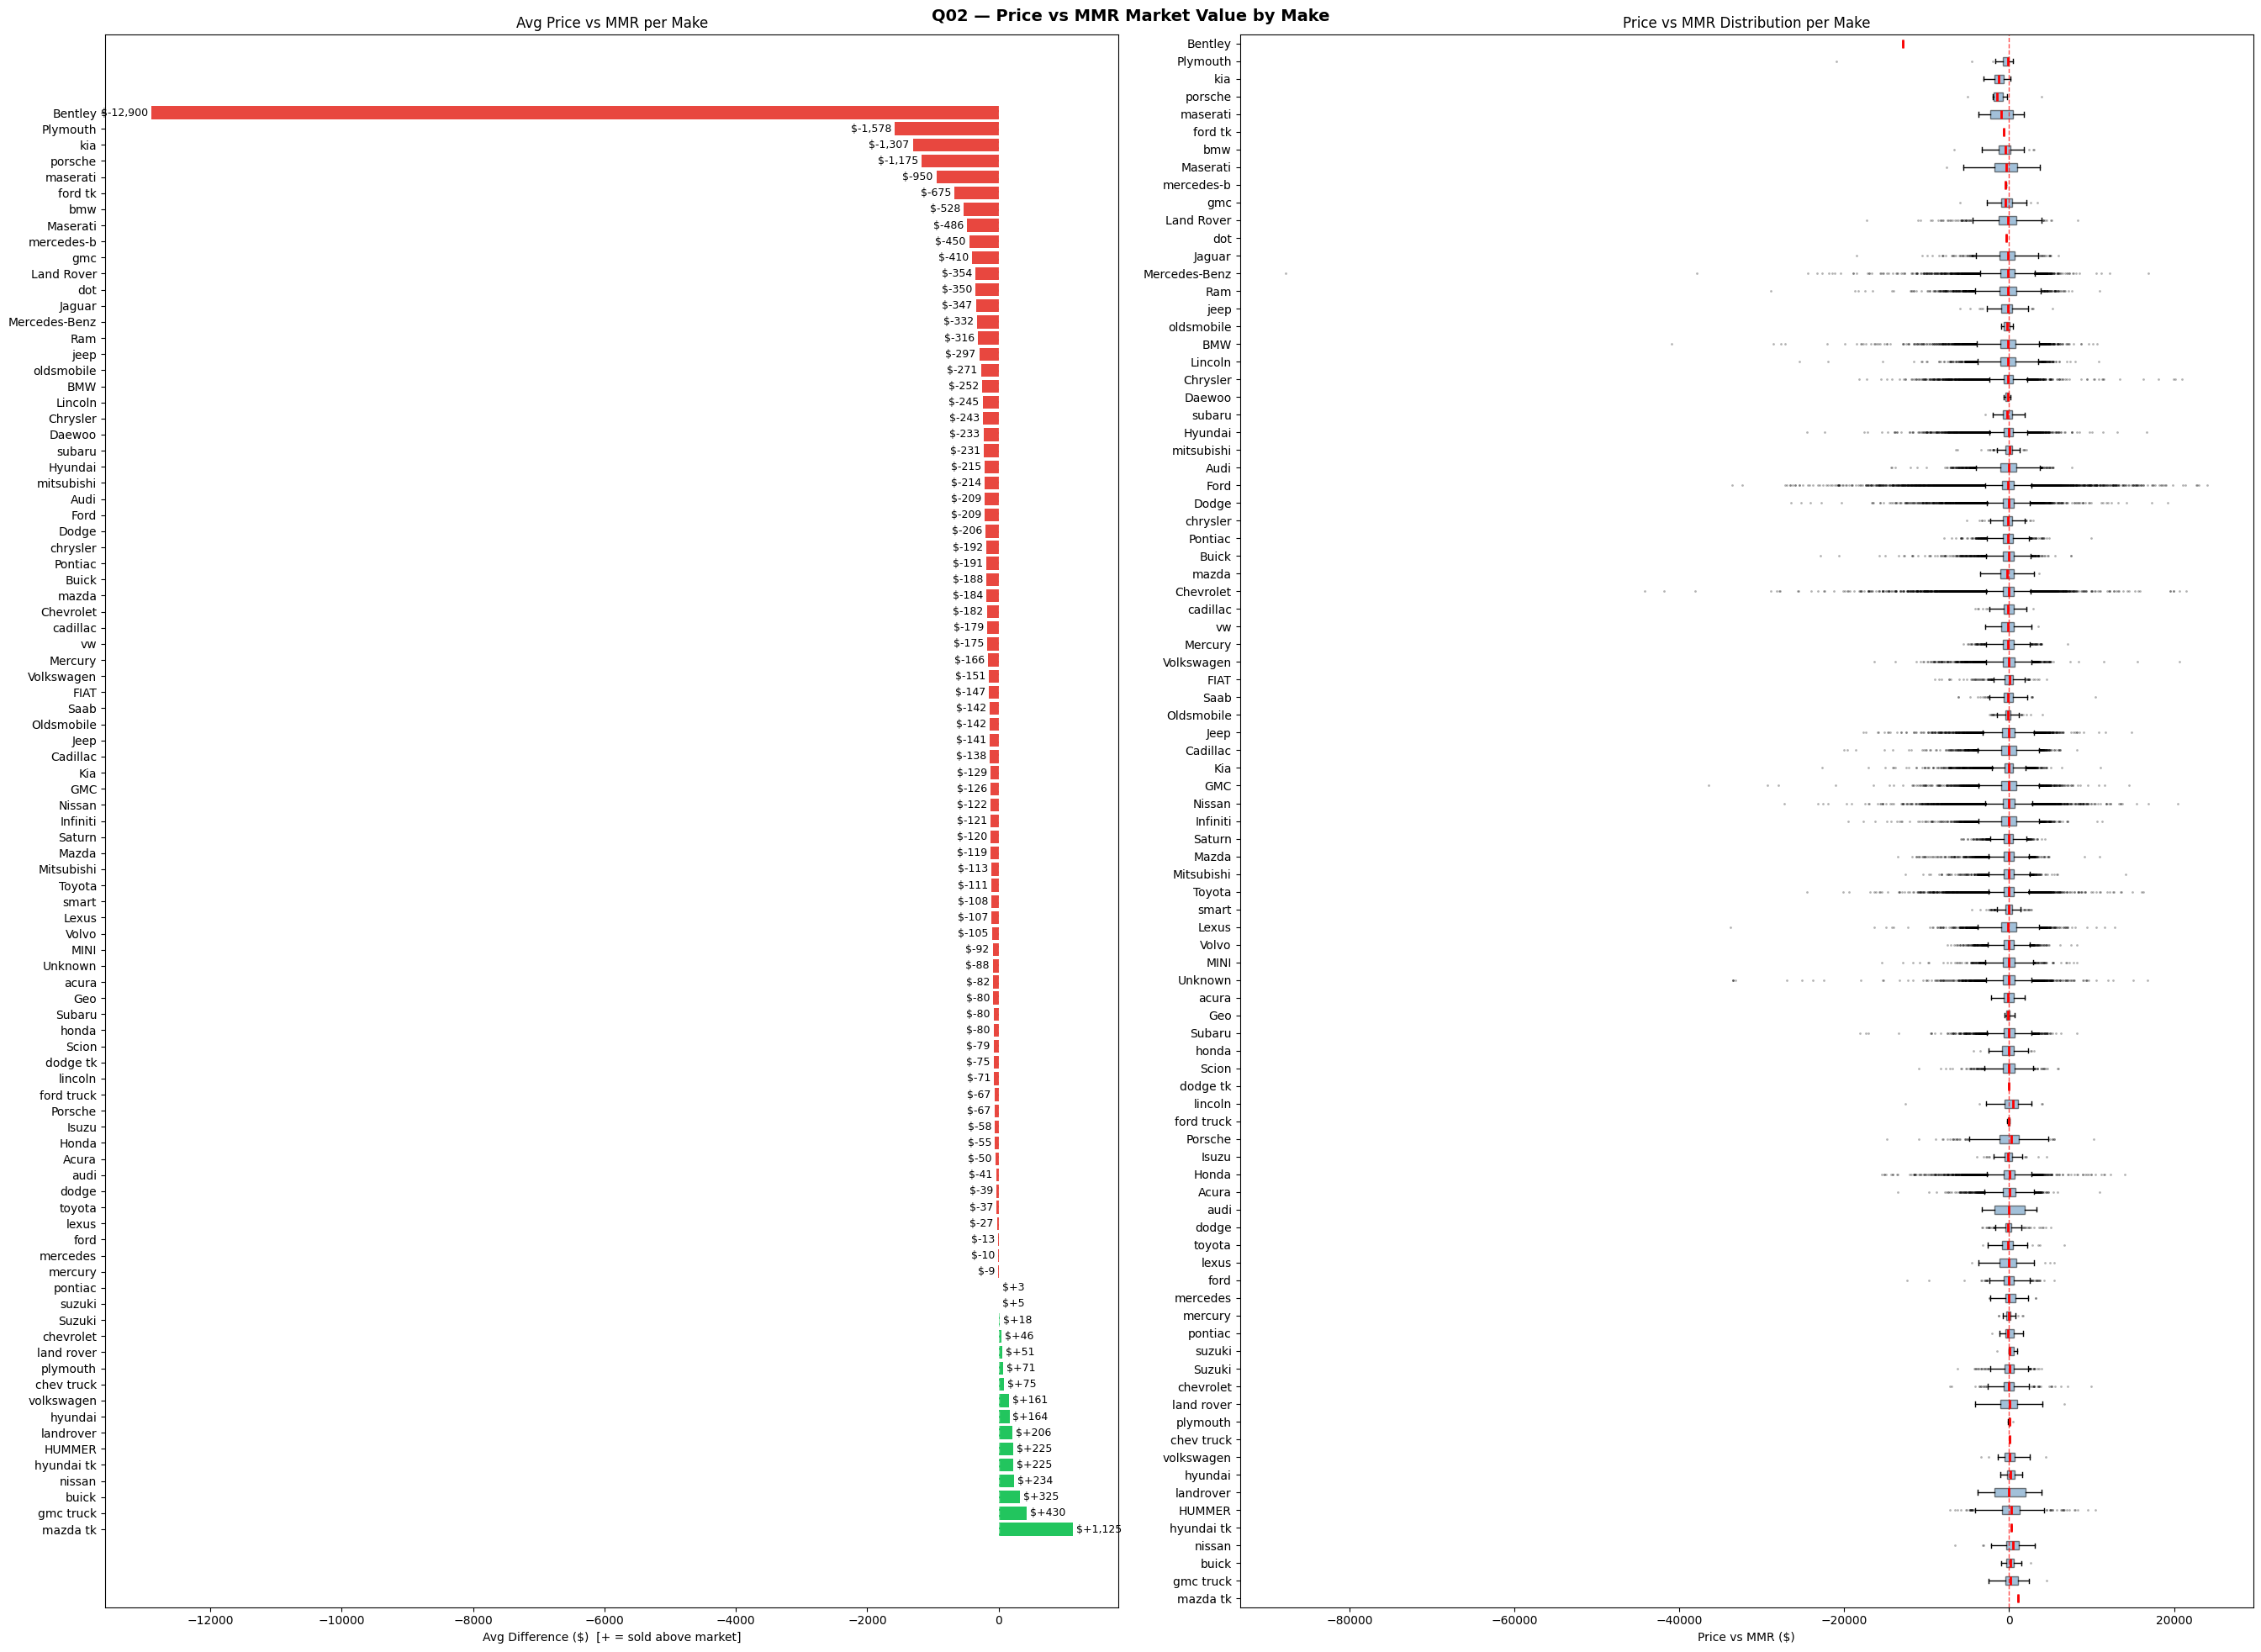


--- Q02 Summary ---
         make       avg_pvm  med_pvm     std_pvm  sales
     mazda tk   1125.000000   1125.0         NaN      1
    gmc truck    429.545455    175.0 1868.716745     11
        buick    325.000000    200.0 1003.587316     13
       nissan    233.802817    425.0 1532.155919     71
   hyundai tk    225.000000    225.0         NaN      1
       HUMMER    224.787402    300.0 2073.240831    762
    landrover    206.000000    -50.0 2184.179384     25
      hyundai    163.750000    125.0  712.735418     20
   volkswagen    161.458333     87.5 1578.678919     24
   chev truck     75.000000     75.0         NaN      1
     plymouth     71.428571     50.0  174.062113      7
   land rover     51.446281     50.0 1776.722455    121
    chevrolet     46.097884    -25.0 1625.043251    378
       Suzuki     17.681091     25.0 1047.151755   1063
       suzuki      5.000000     25.0  930.960525      5
      pontiac      2.777778   -100.0  887.150075     27
      mercury     -8.870968

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(27, 20))
fig.suptitle('Q02 — Price vs MMR Market Value by Make', fontsize=14, fontweight='bold')

# Compute price vs market per make
pvm_by_make = (df.groupby('make')['price_vs_market']
                 .agg(['mean', 'median', 'std', 'count'])
                 .reset_index()
                 .sort_values('mean', ascending=False))

# Bar chart — avg spread
colors = ['#22c55e' if v >= 0 else '#e8473f' for v in pvm_by_make['mean']]
bars = axes[0].barh(pvm_by_make['make'], pvm_by_make['mean'],
                    color=colors, edgecolor='none')
axes[0].axvline(0, color='white', linewidth=1, linestyle='--', alpha=0.5)
axes[0].set_title('Avg Price vs MMR per Make')
axes[0].set_xlabel('Avg Difference ($)  [+ = sold above market]')

# Add value labels
for bar, val in zip(bars, pvm_by_make['mean']):
    axes[0].text(val + (50 if val >= 0 else -50), bar.get_y() + bar.get_height()/2,
                 f"${val:+,.0f}", va='center',
                 ha='left' if val >= 0 else 'right', fontsize=9)

# Box plot — spread per make (shows consistency)
make_order = pvm_by_make['make'].tolist()
data_per_make = [df[df['make'] == m]['price_vs_market'].dropna().values for m in make_order]
bp = axes[1].boxplot(data_per_make, labels=make_order, vert=False,
                     patch_artist=True, notch=False,
                     boxprops=dict(facecolor='steelblue', alpha=0.5),
                     medianprops=dict(color='red', linewidth=2),
                     flierprops=dict(marker='.', markersize=2, alpha=0.3))
axes[1].axvline(0, color='red', linewidth=1, linestyle='--', alpha=0.7)
axes[1].set_title('Price vs MMR Distribution per Make')
axes[1].set_xlabel('Price vs MMR ($)')

plt.tight_layout()
plt.savefig('Price_vs_MMR_Market_Value_by_Make.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n--- Q02 Summary ---")
print(pvm_by_make[['make','mean','median','std','count']]
      .rename(columns={'mean':'avg_pvm','median':'med_pvm','std':'std_pvm','count':'sales'})
      .to_string(index=False))
print(f"\nMakes consistently ABOVE market : {(pvm_by_make['mean'] > 0).sum()}")
print(f"Makes consistently BELOW market : {(pvm_by_make['mean'] < 0).sum()}")

#### Observations:
• Most makes sell below their MMR benchmark, led by Bentley (−$12,900), Plymouth (−$1,578), and luxury brands like Porsche and BMW, indicating auction prices for premium vehicles often fall short of book value.

• Conversely, trucks and mainstream brands (Mazda, GMC, Buick, Nissan) consistently fetch prices above market, showing stronger wholesale demand and tighter supply.

### Q03 — What % of Vehicles Sold Above vs Below MMR?

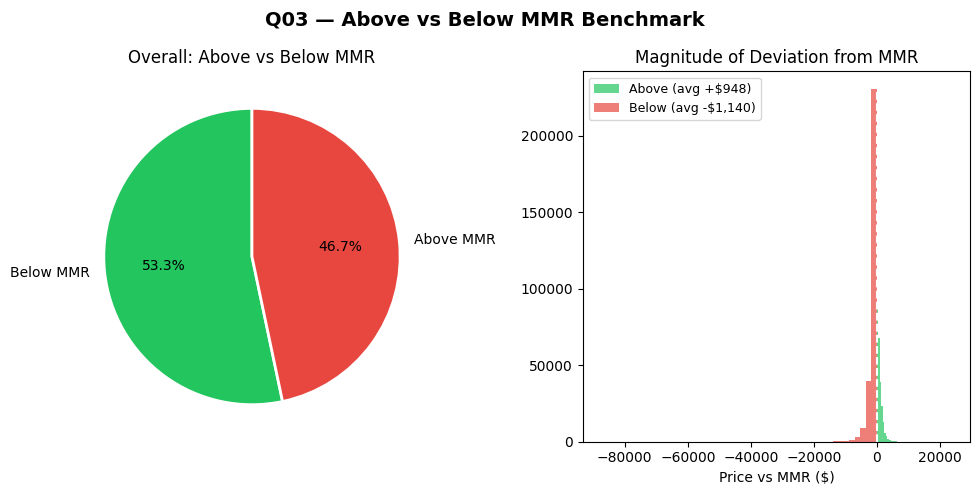


--- Q03 Summary ---
Above MMR : 249,398  (46.7%)
Below MMR : 284,779  (53.3%)

Avg premium when above : +$948
Avg discount when below: -$1,140


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Q03 — Above vs Below MMR Benchmark', fontsize=14, fontweight='bold')

# Create flag column
df['above_mmr'] = df['sellingprice'] > df['mmr']
df['mmr_label'] = df['above_mmr'].map({True: 'Above MMR', False: 'Below MMR'})

# Pie chart — overall
counts = df['mmr_label'].value_counts()
axes[0].pie(counts.values,
            labels=counts.index,
            autopct='%1.1f%%',
            colors=['#22c55e', '#e8473f'],
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Overall: Above vs Below MMR')

# Spread magnitude — how far above/below?
above_vals = df[df['above_mmr']]['price_vs_market']
below_vals = df[~df['above_mmr']]['price_vs_market'].abs()
axes[1].hist(above_vals, bins=50, alpha=0.7, color='#22c55e',
             label=f'Above (avg +${above_vals.mean():,.0f})', edgecolor='none')
axes[1].hist(-below_vals, bins=50, alpha=0.7, color='#e8473f',
             label=f'Below (avg -${below_vals.mean():,.0f})', edgecolor='none')
axes[1].axvline(0, color='white', linewidth=1.5, linestyle='--')
axes[1].set_title('Magnitude of Deviation from MMR')
axes[1].set_xlabel('Price vs MMR ($)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('Above_vs_Below_MMR_Benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
total  = len(df)
n_above = df['above_mmr'].sum()
n_below = total - n_above
print(f"\n--- Q03 Summary ---")
print(f"Above MMR : {n_above:,}  ({n_above/total*100:.1f}%)")
print(f"Below MMR : {n_below:,}  ({n_below/total*100:.1f}%)")
print(f"\nAvg premium when above : +${above_vals.mean():,.0f}")
print(f"Avg discount when below: -${below_vals.mean():,.0f}")

#### Observation:
53.3% of vehicles sold above their MMR benchmark at an average premium of +$948, while 46.7% sold below at an average discount of −$1,140 — revealing an asymmetric market where downside losses outweigh upside gains by 20%, driven by extreme deviations in luxury makes that create a long left tail stretching to −$80,000.

## 🚗 Vehicle Characteristics

### Q04 — How Does Mileage Affect Selling Price?

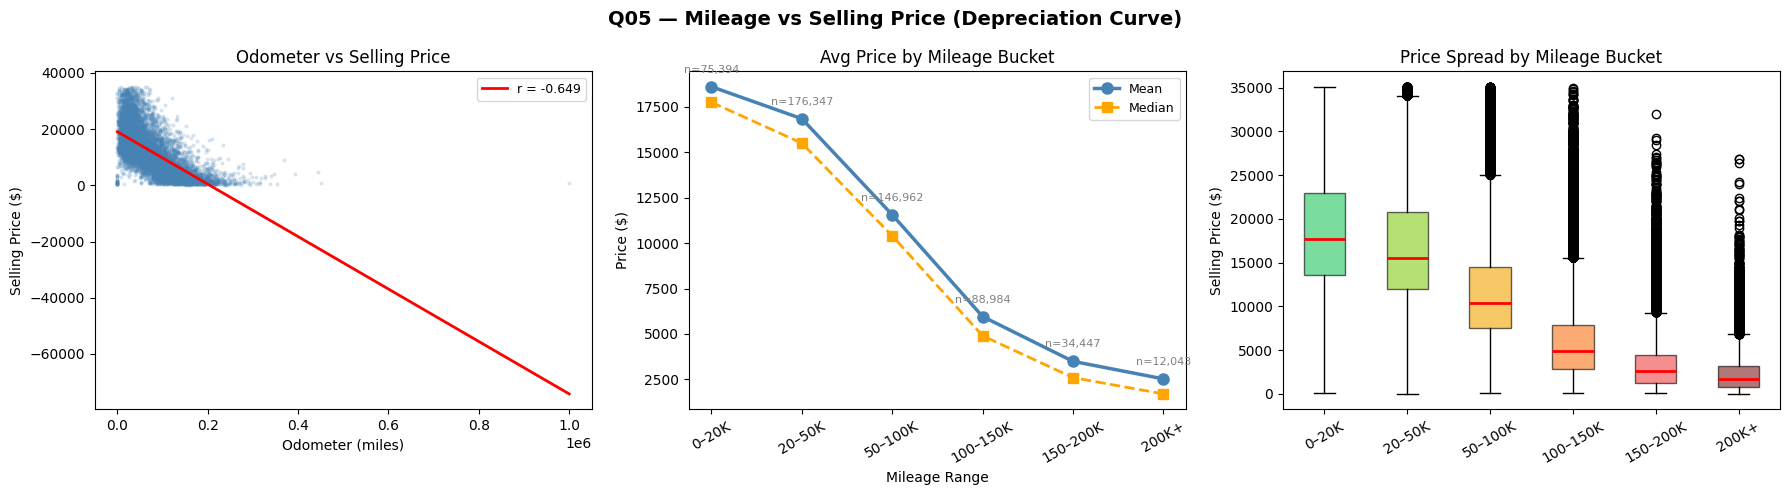


--- Q05 Summary ---
Correlation (odometer vs price) : r = -0.649
Slope : $-0.09 per mile  (i.e. every 10,000 extra miles ≈ $-933 price drop)

Depreciation by mileage bucket:
mileage_bucket    avg_price  med_price  units
         0–20K 18607.399966    17750.0  75394
        20–50K 16844.436696    15500.0 176347
       50–100K 11560.533070    10400.0 146962
      100–150K  5960.319226     4900.0  88984
      150–200K  3494.158882     2600.0  34447
         200K+  2528.823466     1700.0  12043

Price drop from 0–20K → 200K+ : $18,607 → $2,529  (-86.4%)


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Q05 — Mileage vs Selling Price (Depreciation Curve)', 
             fontsize=14, fontweight='bold')

# Sample for performance
sample = df.sample(min(10000, len(df)), random_state=42)

# 1. Scatter plot with regression line
axes[0].scatter(sample['odometer'], sample['sellingprice'],
                alpha=0.15, s=4, color='steelblue')
# Add linear trend line
m, b, r, p, se = stats.linregress(sample['odometer'].dropna(),
                                   sample['sellingprice'].dropna())
x_line = np.linspace(sample['odometer'].min(), sample['odometer'].max(), 100)
axes[0].plot(x_line, m * x_line + b, color='red', linewidth=2,
             label=f'r = {r:.3f}')
axes[0].set_title('Odometer vs Selling Price')
axes[0].set_xlabel('Odometer (miles)')
axes[0].set_ylabel('Selling Price ($)')
axes[0].legend(fontsize=9)

# 2. Mileage bucket avg price (depreciation steps)
df['mileage_bucket'] = pd.cut(df['odometer'],
    bins=[0, 20000, 50000, 100000, 150000, 200000, 999999],
    labels=['0–20K','20–50K','50–100K','100–150K','150–200K','200K+'])

bucket_avg = df.groupby('mileage_bucket', observed=True)['sellingprice'].agg(
    ['mean','median','count']).reset_index()

axes[1].plot(bucket_avg['mileage_bucket'], bucket_avg['mean'],
             marker='o', color='steelblue', linewidth=2.5,
             markersize=8, label='Mean')
axes[1].plot(bucket_avg['mileage_bucket'], bucket_avg['median'],
             marker='s', color='orange', linewidth=2, linestyle='--',
             markersize=7, label='Median')
axes[1].set_title('Avg Price by Mileage Bucket')
axes[1].set_xlabel('Mileage Range')
axes[1].set_ylabel('Price ($)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=9)

# Add count labels
for _, row in bucket_avg.iterrows():
    axes[1].annotate(f"n={int(row['count']):,}",
                     (row['mileage_bucket'], row['mean']),
                     textcoords='offset points', xytext=(0, 10),
                     fontsize=8, ha='center', color='gray')

# 3. Box plot per mileage bucket
data_buckets = [df[df['mileage_bucket'] == b]['sellingprice'].dropna().values
                for b in bucket_avg['mileage_bucket']]
bp = axes[2].boxplot(data_buckets,
                     labels=bucket_avg['mileage_bucket'].tolist(),
                     patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))
colors = ['#22c55e','#84cc16','#f0a500','#f97316','#ef4444','#7f1d1d']
for patch, col in zip(bp['boxes'], colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.6)
axes[2].set_title('Price Spread by Mileage Bucket')
axes[2].set_ylabel('Selling Price ($)')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('Mileage_VS_Selling_Price.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("\n--- Q05 Summary ---")
print(f"Correlation (odometer vs price) : r = {r:.3f}")
print(f"Slope : ${m:,.2f} per mile  "
      f"(i.e. every 10,000 extra miles ≈ ${m*10000:,.0f} price drop)")
print(f"\nDepreciation by mileage bucket:")
print(bucket_avg.rename(columns={'mean':'avg_price','median':'med_price',
                                  'count':'units'}).to_string(index=False))

# % price drop from lowest to highest bucket
low  = bucket_avg['mean'].iloc[0]
high = bucket_avg['mean'].iloc[-1]
print(f"\nPrice drop from 0–20K → 200K+ : "
      f"${low:,.0f} → ${high:,.0f}  ({(high-low)/low*100:.1f}%)")

#### Observation:
Mileage is the strongest single predictor of vehicle selling price (r = −0.649), with every 10,000 additional miles reducing value by approximately $933 — but the depreciation curve is non-linear, accelerating sharply at the 50,000-mile threshold where prices drop 31.4% compared to just 9.5% in the prior bracket, and total price erosion reaches 86.4% by 200,000+ miles.

### Q05 — Which Model Years Have the Highest Avg Resale Value?

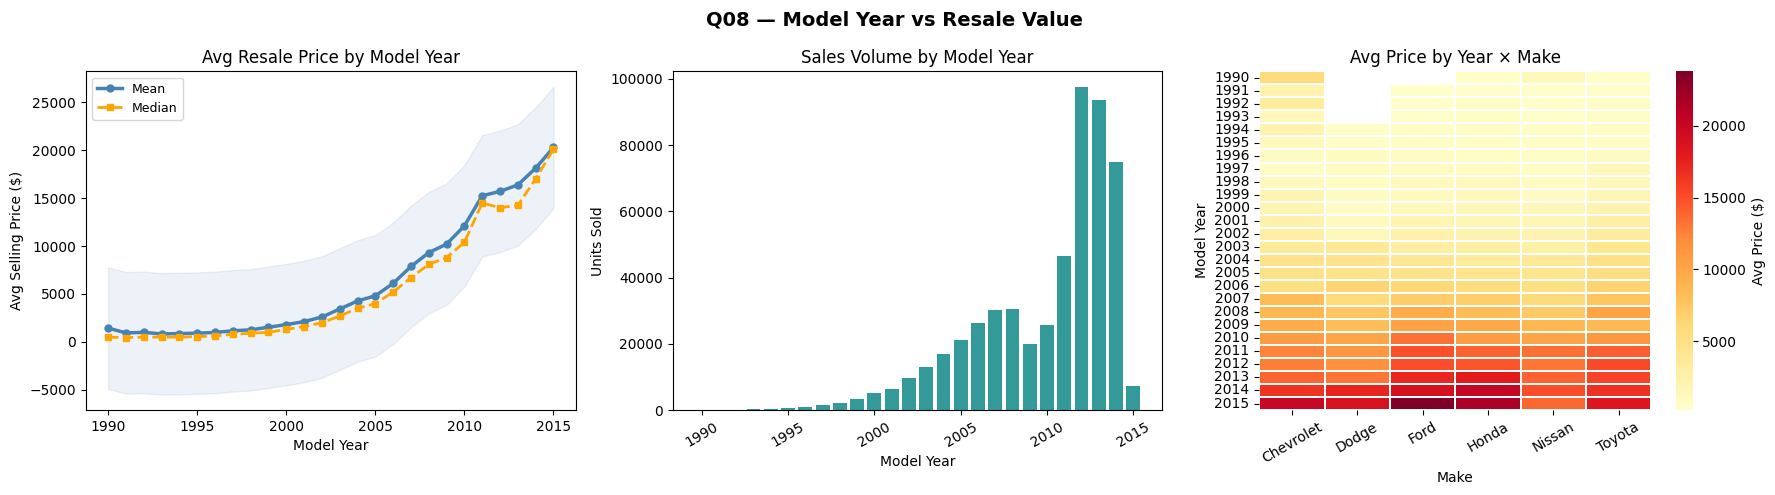


--- Q08 Summary ---
Highest avg resale value:
 year    avg_price  units
 2015 20289.771529   7397
 2014 18126.763928  74778
 2013 16380.086427  93501
 2012 15709.454316  97375
 2011 15246.668026  46606

Lowest avg resale value:
 year  avg_price  units
 1993 833.902439    205
 1994 870.599490    392
 1995 912.501420    704
 1991 943.656716     67
 1996 986.529412    850

Best volume year:
  2012 — 97,375 units @ avg $15,709


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Q08 — Model Year vs Resale Value', 
             fontsize=14, fontweight='bold')

# 1. Avg price per model year
year_stats = (df.groupby('year')['sellingprice']
                .agg(['mean','median','count'])
                .reset_index()
                .sort_values('year'))
year_stats = year_stats[year_stats['count'] >= 30]  # filter thin years

axes[0].plot(year_stats['year'], year_stats['mean'],
             marker='o', ms=5, color='steelblue',
             linewidth=2.5, label='Mean')
axes[0].plot(year_stats['year'], year_stats['median'],
             marker='s', ms=4, color='orange',
             linewidth=2, linestyle='--', label='Median')
axes[0].fill_between(year_stats['year'],
                     year_stats['mean'] - year_stats['mean'].std(),
                     year_stats['mean'] + year_stats['mean'].std(),
                     alpha=0.1, color='steelblue')
axes[0].set_title('Avg Resale Price by Model Year')
axes[0].set_xlabel('Model Year')
axes[0].set_ylabel('Avg Selling Price ($)')
axes[0].legend(fontsize=9)

# 2. Volume sold per model year
axes[1].bar(year_stats['year'], year_stats['count'],
            color='teal', edgecolor='none', alpha=0.8)
axes[1].set_title('Sales Volume by Model Year')
axes[1].set_xlabel('Model Year')
axes[1].set_ylabel('Units Sold')
axes[1].tick_params(axis='x', rotation=30)

# 3. Heatmap — avg price by model year × make (top 6 makes)
top6 = df['make'].value_counts().head(6).index.tolist()
pivot = (df[df['make'].isin(top6)]
         .groupby(['year','make'])['sellingprice']
         .mean()
         .unstack()
         .sort_index())

sns.heatmap(pivot, ax=axes[2], cmap='YlOrRd', fmt='.0f',
            linewidths=0.3, cbar_kws={'label':'Avg Price ($)'})
axes[2].set_title('Avg Price by Year × Make')
axes[2].set_xlabel('Make')
axes[2].set_ylabel('Model Year')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('Model_Year_vs_Resale_Value.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Q08 Summary ---")
print(f"Highest avg resale value:")
print(year_stats.nlargest(5,'mean')[['year','mean','count']]
      .rename(columns={'mean':'avg_price','count':'units'})
      .to_string(index=False))
print(f"\nLowest avg resale value:")
print(year_stats.nsmallest(5,'mean')[['year','mean','count']]
      .rename(columns={'mean':'avg_price','count':'units'})
      .to_string(index=False))
print(f"\nBest volume year:")
best_vol = year_stats.loc[year_stats['count'].idxmax()]
print(f"  {int(best_vol['year'])} — {int(best_vol['count']):,} units "
      f"@ avg ${best_vol['mean']:,.0f}")

#### Observation:
Resale value grows exponentially with model year recency — rising from just $834 for 1993 models to $20,290 for 2015 models (+2,333%) — with 2012 representing the market's sweet spot of highest volume (97,375 units) and strong pricing ($15,709 avg), while the heatmap confirms Toyota and Honda sustain value better than domestic brands across all model year cohorts.

## 📅 Sales Trends Over Time

### Q06 — Which Months/Quarters Have the Highest Sales Volume and Revenue?

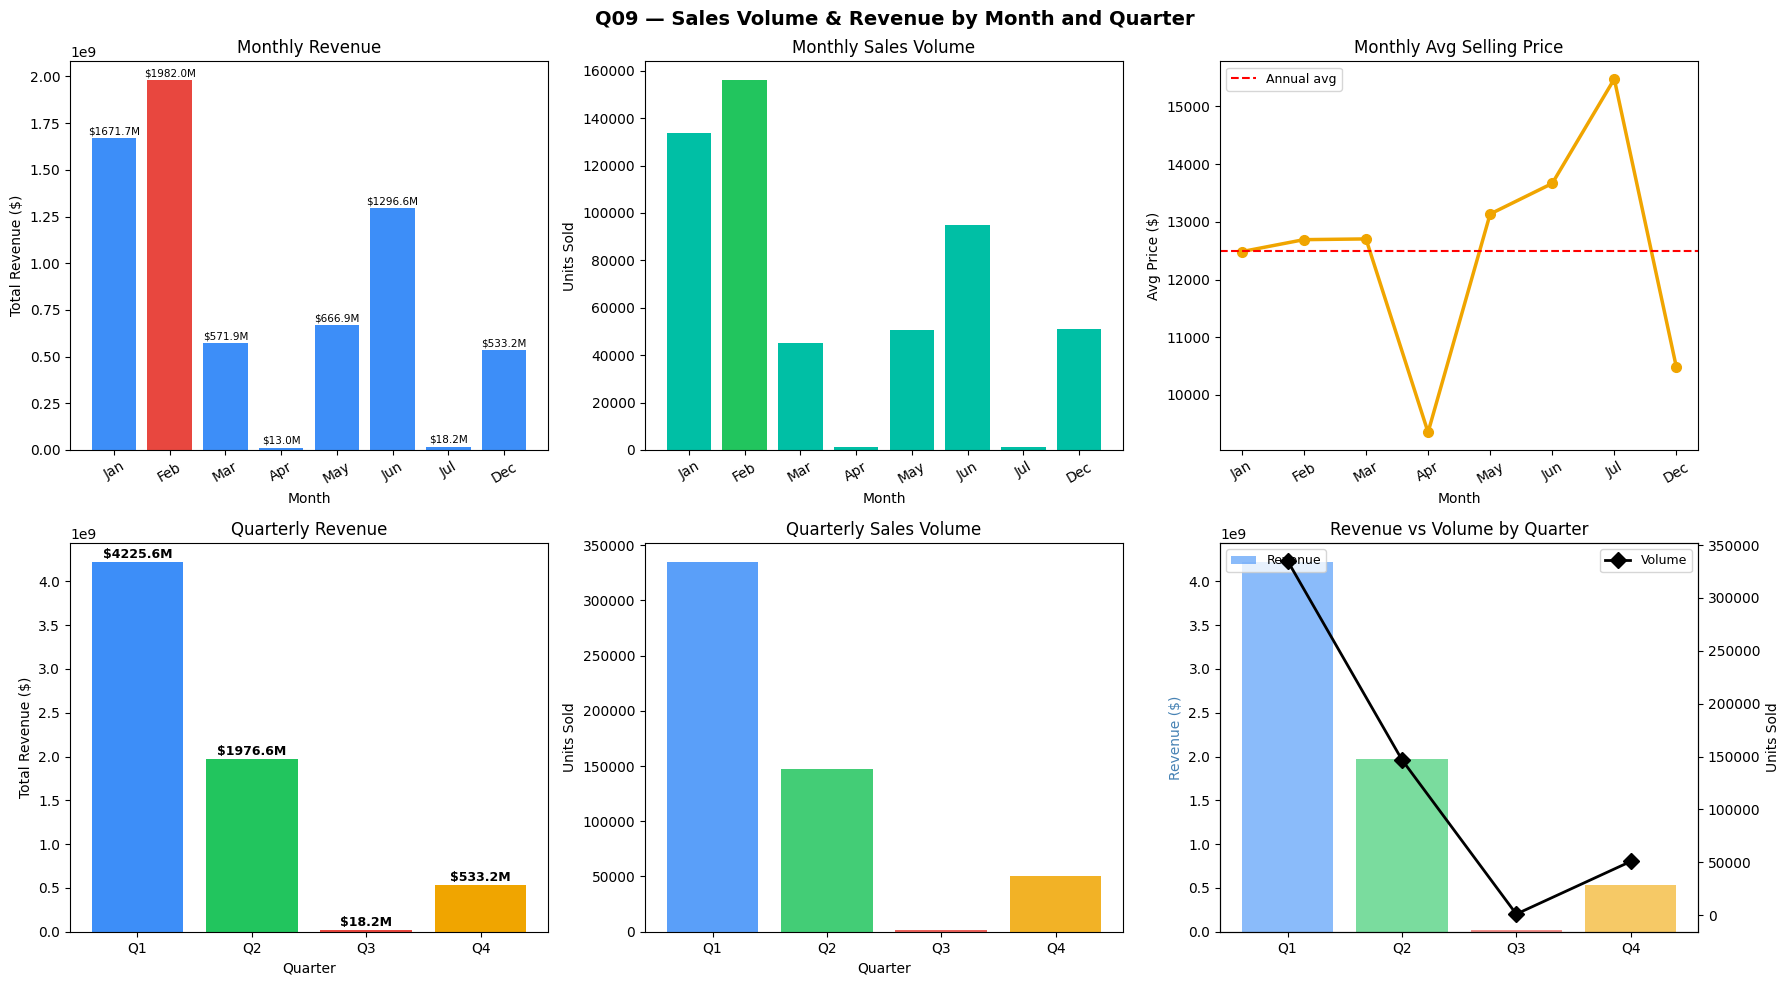


--- Q09 Summary ---
Best month by revenue : Feb  $1,982,014,918
Best month by volume  : Feb  156,167 units
Best quarter          : Q1  $4,225,607,106

Monthly breakdown:
month_name      revenue  volume  avg_price
       Jan 1671657346.0  133902    12484.0
       Feb 1982014918.0  156167    12692.0
       Mar  571934842.0   45019    12704.0
       Apr   13037093.0    1394     9352.0
       May  666932966.0   50770    13136.0
       Jun 1296589426.0   94877    13666.0
       Jul   18154264.0    1173    15477.0
       Dec  533181355.0   50875    10480.0


In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Q09 — Sales Volume & Revenue by Month and Quarter',
             fontsize=14, fontweight='bold')

# --- Monthly Revenue ---
monthly = (df.groupby('sale_month')
             .agg(revenue=('sellingprice','sum'),
                  volume=('sellingprice','count'))
             .reset_index()
             .sort_values('sale_month'))

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
monthly['month_name'] = monthly['sale_month'].apply(lambda x: month_labels[x-1])

# Monthly Revenue bar
colors_m = ['#e8473f' if v == monthly['revenue'].max()
            else '#3d8ef8' for v in monthly['revenue']]
bars = axes[0,0].bar(monthly['month_name'], monthly['revenue'],
                     color=colors_m, edgecolor='none')
axes[0,0].set_title('Monthly Revenue')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Total Revenue ($)')
axes[0,0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, monthly['revenue']):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + monthly['revenue'].max()*0.01,
                   f"${val/1e6:.1f}M", ha='center', fontsize=7.5)

# Monthly Volume bar
colors_v = ['#22c55e' if v == monthly['volume'].max()
            else '#00bfa5' for v in monthly['volume']]
axes[0,1].bar(monthly['month_name'], monthly['volume'],
              color=colors_v, edgecolor='none')
axes[0,1].set_title('Monthly Sales Volume')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Units Sold')
axes[0,1].tick_params(axis='x', rotation=30)

# Monthly Avg Price line
axes[0,2].plot(monthly['month_name'], monthly['revenue']/monthly['volume'],
               marker='o', color='#f0a500', linewidth=2.5, markersize=7)
axes[0,2].axhline((monthly['revenue']/monthly['volume']).mean(),
                  color='red', linestyle='--', linewidth=1.5,
                  label='Annual avg')
axes[0,2].set_title('Monthly Avg Selling Price')
axes[0,2].set_xlabel('Month')
axes[0,2].set_ylabel('Avg Price ($)')
axes[0,2].tick_params(axis='x', rotation=30)
axes[0,2].legend(fontsize=9)

# --- Quarterly ---
quarterly = (df.groupby('quarter')
               .agg(revenue=('sellingprice','sum'),
                    volume=('sellingprice','count'))
               .reset_index()
               .sort_values('quarter'))

qtr_colors = ['#3d8ef8','#22c55e','#e8473f','#f0a500']

# Quarterly Revenue
axes[1,0].bar(quarterly['quarter'], quarterly['revenue'],
              color=qtr_colors, edgecolor='none')
axes[1,0].set_title('Quarterly Revenue')
axes[1,0].set_xlabel('Quarter')
axes[1,0].set_ylabel('Total Revenue ($)')
for i, (_, row) in enumerate(quarterly.iterrows()):
    axes[1,0].text(i, row['revenue'] + quarterly['revenue'].max()*0.01,
                   f"${row['revenue']/1e6:.1f}M",
                   ha='center', fontsize=9, fontweight='bold')

# Quarterly Volume
axes[1,1].bar(quarterly['quarter'], quarterly['volume'],
              color=qtr_colors, edgecolor='none', alpha=0.85)
axes[1,1].set_title('Quarterly Sales Volume')
axes[1,1].set_xlabel('Quarter')
axes[1,1].set_ylabel('Units Sold')

# Revenue + Volume dual axis
ax2 = axes[1,2].twinx()
axes[1,2].bar(quarterly['quarter'], quarterly['revenue'],
              color=qtr_colors, edgecolor='none', alpha=0.6, label='Revenue')
ax2.plot(quarterly['quarter'], quarterly['volume'],
         marker='D', color='black', linewidth=2,
         markersize=8, label='Volume')
axes[1,2].set_title('Revenue vs Volume by Quarter')
axes[1,2].set_ylabel('Revenue ($)', color='steelblue')
ax2.set_ylabel('Units Sold', color='black')
axes[1,2].legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('Sales_volumn_&_Revenue_vy_Month_&_Quarter.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("\n--- Q09 Summary ---")
best_month_rev = monthly.loc[monthly['revenue'].idxmax()]
best_month_vol = monthly.loc[monthly['volume'].idxmax()]
best_qtr       = quarterly.loc[quarterly['revenue'].idxmax()]

print(f"Best month by revenue : {best_month_rev['month_name']}"
      f"  ${best_month_rev['revenue']:,.0f}")
print(f"Best month by volume  : {best_month_vol['month_name']}"
      f"  {best_month_vol['volume']:,} units")
print(f"Best quarter          : {best_qtr['quarter']}"
      f"  ${best_qtr['revenue']:,.0f}")
print(f"\nMonthly breakdown:")
monthly['avg_price'] = (monthly['revenue'] / monthly['volume']).round(0)
print(monthly[['month_name','revenue','volume','avg_price']].to_string(index=False))

## 🗺️ Regional & Seller Analysis

### Q07 — Revenue & Avg Price by State 

State stats shape  : (38, 8)
state  total_revenue    avg_price  median_price  total_units      avg_mmr     avg_pvm  revenue_share
   fl   1021235522.0 12861.260415       12300.0        79404 13006.760365 -145.499950          15.12
   ca    875081507.0 12832.612433       11800.0        68192 12819.435931   13.176502          12.96
   pa    753812267.0 14800.075923       13900.0        50933 14977.074785 -176.998861          11.16
   tx    541244759.0 12311.930097       11500.0        43961 12548.641409 -236.711312           8.01
   ga    398425642.0 12013.799361       11200.0        33164 12034.100983  -20.301622           5.90
   nj    332404899.0 12552.581058       12000.0        26481 13100.245459 -547.664401           4.92
   il    326192125.0 14287.246507       13700.0        22831 14464.622662 -177.376155           4.83
   tn    318397088.0 16025.623515       15500.0        19868 15959.074894   66.548621           4.71
   oh    257564632.0 12713.590602       12100.0        20259 1

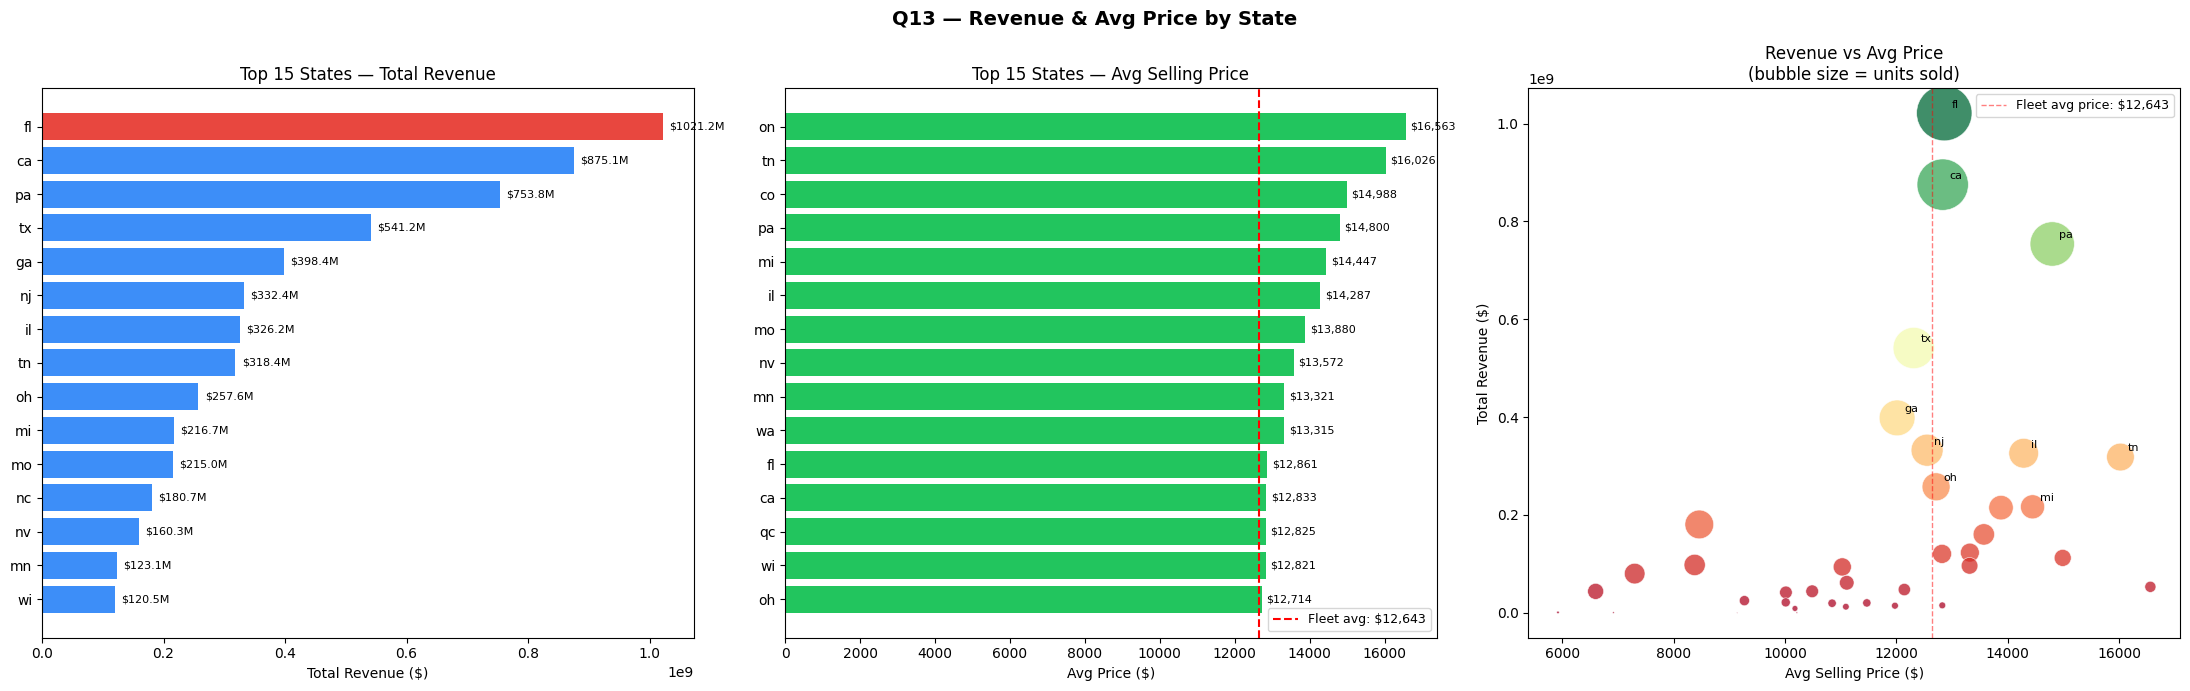

In [26]:
# ── 1. Aggregate by state ──────────────────────────────────────────
state_stats = (df.groupby('state')
                 .agg(
                     total_revenue  = ('sellingprice', 'sum'),
                     avg_price      = ('sellingprice', 'mean'),
                     median_price   = ('sellingprice', 'median'),
                     total_units    = ('sellingprice', 'count'),
                     avg_mmr        = ('mmr',          'mean'),
                 )
                 .reset_index())

state_stats['avg_pvm']       = state_stats['avg_price'] - state_stats['avg_mmr']
state_stats['revenue_share'] = (state_stats['total_revenue'] /
                                 state_stats['total_revenue'].sum() * 100).round(2)
state_stats = state_stats.sort_values('total_revenue', ascending=False)

print("State stats shape  :", state_stats.shape)
print(state_stats.head(10).to_string(index=False))




fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Q13 — Revenue & Avg Price by State', 
             fontsize=14, fontweight='bold')

top_n = 15   # show top 15 states for readability

# --- Chart 1: Total Revenue (top 15) ---
top_rev = state_stats.head(top_n).sort_values('total_revenue')
colors_rev = ['#e8473f' if i == len(top_rev)-1
              else '#3d8ef8' for i in range(len(top_rev))]

bars1 = axes[0].barh(top_rev['state'], top_rev['total_revenue'],
                     color=colors_rev, edgecolor='none')
axes[0].set_title(f'Top {top_n} States — Total Revenue')
axes[0].set_xlabel('Total Revenue ($)')
for bar, val in zip(bars1, top_rev['total_revenue']):
    axes[0].text(bar.get_width() + top_rev['total_revenue'].max()*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'${val/1e6:.1f}M', va='center', fontsize=8)

# --- Chart 2: Avg Price per Vehicle (top 15) ---
top_avg = state_stats.nlargest(top_n, 'avg_price').sort_values('avg_price')
fleet_avg = df['sellingprice'].mean()
colors_avg = ['#22c55e' if v >= fleet_avg else '#f0a500'
              for v in top_avg['avg_price']]

bars2 = axes[1].barh(top_avg['state'], top_avg['avg_price'],
                     color=colors_avg, edgecolor='none')
axes[1].axvline(fleet_avg, color='red', linestyle='--',
                linewidth=1.5,
                label=f'Fleet avg: ${fleet_avg:,.0f}')
axes[1].set_title(f'Top {top_n} States — Avg Selling Price')
axes[1].set_xlabel('Avg Price ($)')
axes[1].legend(fontsize=9)
for bar, val in zip(bars2, top_avg['avg_price']):
    axes[1].text(bar.get_width() + fleet_avg*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=8)

# --- Chart 3: Revenue Share bubble (revenue vs avg price) ---
axes[2].scatter(state_stats['avg_price'],
                state_stats['total_revenue'],
                s=state_stats['total_units']/50,
                c=state_stats['total_revenue'],
                cmap='RdYlGn', alpha=0.75,
                edgecolors='white', linewidth=0.5)
# Label top 10 states
for _, row in state_stats.head(10).iterrows():
    axes[2].annotate(row['state'],
                     (row['avg_price'], row['total_revenue']),
                     textcoords='offset points',
                     xytext=(5, 4), fontsize=8, color='black')
axes[2].axvline(fleet_avg, color='red', linestyle='--',
                linewidth=1, alpha=0.5,
                label=f'Fleet avg price: ${fleet_avg:,.0f}')
axes[2].set_title('Revenue vs Avg Price\n(bubble size = units sold)')
axes[2].set_xlabel('Avg Selling Price ($)')
axes[2].set_ylabel('Total Revenue ($)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('Revenue_&_Avg_Price_by_State.png', dpi=150, bbox_inches='tight')
plt.show()

In [122]:
# ── 4. Full Summary Table ──────────────────────────────────────────
print("\n--- Q13 Full Summary ---")
print(f"\nTotal states in dataset : {len(state_stats)}")
print(f"Fleet avg selling price : ${fleet_avg:,.0f}")

print(f"\nTop 10 states by TOTAL REVENUE:")
print(state_stats[['state','total_revenue','total_units',
                   'avg_price','revenue_share']]
      .head(10)
      .rename(columns={'total_revenue':'revenue',
                       'total_units'  :'units',
                       'avg_price'    :'avg_price',
                       'revenue_share':'share_%'})
      .to_string(index=False))

print(f"\nTop 10 states by AVG PRICE per vehicle:")
print(state_stats.nlargest(10,'avg_price')
      [['state','avg_price','median_price','total_units','avg_pvm']]
      .rename(columns={'avg_price'    :'avg_price',
                       'median_price' :'med_price',
                       'total_units'  :'units',
                       'avg_pvm'      :'avg_vs_mmr'})
      .to_string(index=False))

print(f"\nBottom 5 states by avg price:")
print(state_stats.nsmallest(5,'avg_price')
      [['state','avg_price','total_units']]
      .to_string(index=False))

# Revenue concentration
top5_share = state_stats.head(5)['revenue_share'].sum()
top10_share = state_stats.head(10)['revenue_share'].sum()
print(f"\nRevenue concentration:")
print(f"  Top 5  states = {top5_share:.1f}% of total revenue")
print(f"  Top 10 states = {top10_share:.1f}% of total revenue")


--- Q13 Full Summary ---

Total states in dataset : 38
Fleet avg selling price : $12,643

Top 10 states by TOTAL REVENUE:
state      revenue  units    avg_price  share_%
   fl 1021235522.0  79404 12861.260415    15.12
   ca  875081507.0  68192 12832.612433    12.96
   pa  753812267.0  50933 14800.075923    11.16
   tx  541244759.0  43961 12311.930097     8.01
   ga  398425642.0  33164 12013.799361     5.90
   nj  332404899.0  26481 12552.581058     4.92
   il  326192125.0  22831 14287.246507     4.83
   tn  318397088.0  19868 16025.623515     4.71
   oh  257564632.0  20259 12713.590602     3.81
   mi  216688656.0  14999 14446.873525     3.21

Top 10 states by AVG PRICE per vehicle:
state    avg_price  med_price  units  avg_vs_mmr
   on 16563.266895    17600.0   3211   82.777951
   tn 16025.623515    15500.0  19868   66.548621
   co 14988.446150    14200.0   7493   37.538636
   pa 14800.075923    13900.0  50933 -176.998861
   mi 14446.873525    13600.0  14999 -349.194546
   il 14287.24

#### Observation:
Florida dominates total revenue at $1.02 billion, driven purely by auction volume, while Ontario (Canada) and Tennessee lead average selling price at $16,663 and $16,026, respectively — revealing that high-revenue states and high-price states are almost entirely different, with Pennsylvania and Tennessee being the only states that rank strongly in both dimensions simultaneously.

## 🔗 Correlation & Multivariate

### Q08 — Correlation Analysis: Which Feature Drives Selling Price Most?

In [28]:
# ── 1. Select numeric columns ──────────────────────────────────────
corr_cols = ['sellingprice', 'mmr', 'odometer', 'condition', 'vehicle_age']
df_corr = df[corr_cols].dropna()

print(f"Rows used for correlation : {len(df_corr):,}")
print(f"\nDescriptive stats:")
print(df_corr.describe().round(2).to_string())

Rows used for correlation : 534,177

Descriptive stats:
       sellingprice        mmr   odometer  condition  vehicle_age
count     534177.00  534177.00  534177.00  534177.00    534177.00
mean       12642.82   12807.89   69664.84      30.62         4.95
std         7773.13    7721.99   53695.42      13.20         3.97
min            1.00      25.00       1.00       1.00        -1.00
25%         6600.00    6875.00   29314.00      24.00         2.00
50%        11900.00   12000.00   53740.00      35.00         3.00
75%        17500.00   17550.00  100816.00      41.00         8.00
max        35100.00  110000.00  999999.00      49.00        33.00


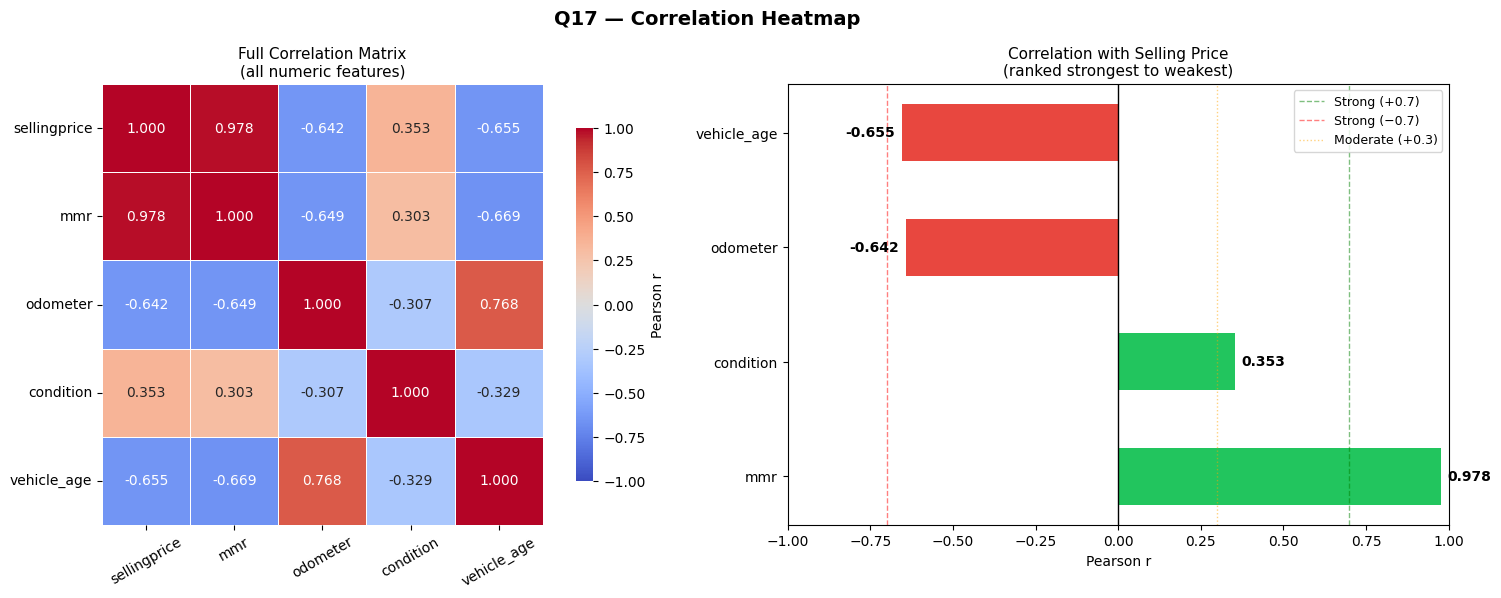

In [29]:
# ── 2. Pearson Correlation Heatmap ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Q17 — Correlation Heatmap', fontsize=14, fontweight='bold')

# Full heatmap
corr_matrix = df_corr.corr(method='pearson')

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True          # upper triangle only

sns.heatmap(corr_matrix,
            ax=axes[0],
            annot=True,
            fmt='.3f',
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5,
            linecolor='white',
            square=True,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
axes[0].set_title('Full Correlation Matrix\n(all numeric features)',
                  fontsize=11)
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

# Focused heatmap — only correlations WITH sellingprice
corr_with_price = (corr_matrix[['sellingprice']]
                   .drop('sellingprice')
                   .sort_values('sellingprice', ascending=False))

bar_colors = ['#22c55e' if v > 0 else '#e8473f'
              for v in corr_with_price['sellingprice']]
bars = axes[1].barh(corr_with_price.index,
                    corr_with_price['sellingprice'],
                    color=bar_colors, edgecolor='none', height=0.5)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].axvline(0.7,  color='green',  linestyle='--',
                linewidth=1, alpha=0.5, label='Strong (+0.7)')
axes[1].axvline(-0.7, color='red',    linestyle='--',
                linewidth=1, alpha=0.5, label='Strong (−0.7)')
axes[1].axvline(0.3,  color='orange', linestyle=':',
                linewidth=1, alpha=0.5, label='Moderate (+0.3)')
axes[1].set_title('Correlation with Selling Price\n(ranked strongest to weakest)',
                  fontsize=11)
axes[1].set_xlabel('Pearson r')
axes[1].legend(fontsize=9)
axes[1].set_xlim(-1, 1)

# Value labels on bars
for bar, val in zip(bars, corr_with_price['sellingprice']):
    offset = 0.02 if val >= 0 else -0.02
    ha     = 'left' if val >= 0 else 'right'
    axes[1].text(val + offset,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', ha=ha,
                 fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('Correlation_Heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


Building pairplot on 5,000 sampled rows...


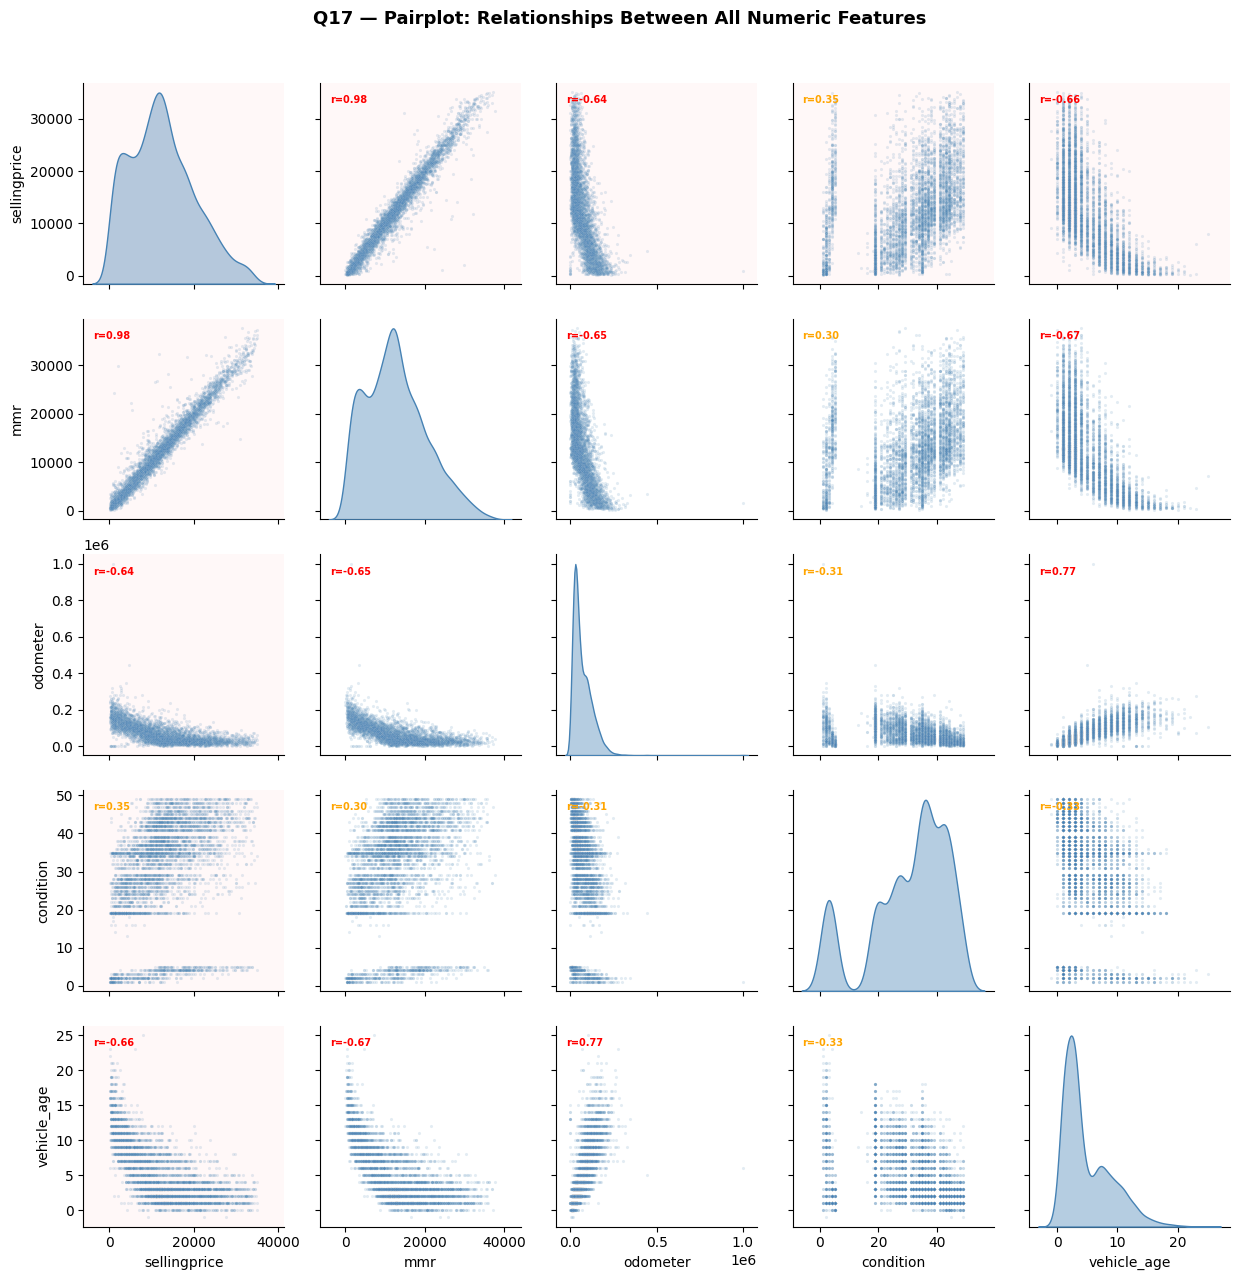

In [30]:
# ── 3. Pairplot ────────────────────────────────────────────────────
# Sample for performance — pairplot is slow on large datasets
sample_n = min(5000, len(df_corr))
df_sample = df_corr.sample(sample_n, random_state=42)

print(f"\nBuilding pairplot on {sample_n:,} sampled rows...")

g = sns.pairplot(df_sample,
                 diag_kind='kde',
                 plot_kws=dict(alpha=0.15, s=5, color='steelblue'),
                 diag_kws=dict(color='steelblue', fill=True, alpha=0.4))

g.figure.suptitle(
    'Q17 — Pairplot: Relationships Between All Numeric Features',
    y=1.02, fontsize=13, fontweight='bold')

# Highlight the sellingprice row/column in red
for i, ax in enumerate(g.axes[0]):          # top row = sellingprice
    ax.set_facecolor('#fff8f8')
for row in g.axes:
    row[0].set_facecolor('#fff8f8')         # left col = sellingprice

# Add r value annotations on off-diagonal plots
for i, row_var in enumerate(corr_cols):
    for j, col_var in enumerate(corr_cols):
        if i != j:
            r_val = corr_matrix.loc[row_var, col_var]
            g.axes[i][j].annotate(
                f'r={r_val:.2f}',
                xy=(0.05, 0.90),
                xycoords='axes fraction',
                fontsize=7,
                color='red' if abs(r_val) >= 0.6
                       else ('orange' if abs(r_val) >= 0.3
                             else 'gray'),
                fontweight='bold')

plt.tight_layout()
plt.savefig('pairplot.png', dpi=120,
            bbox_inches='tight')
plt.show()

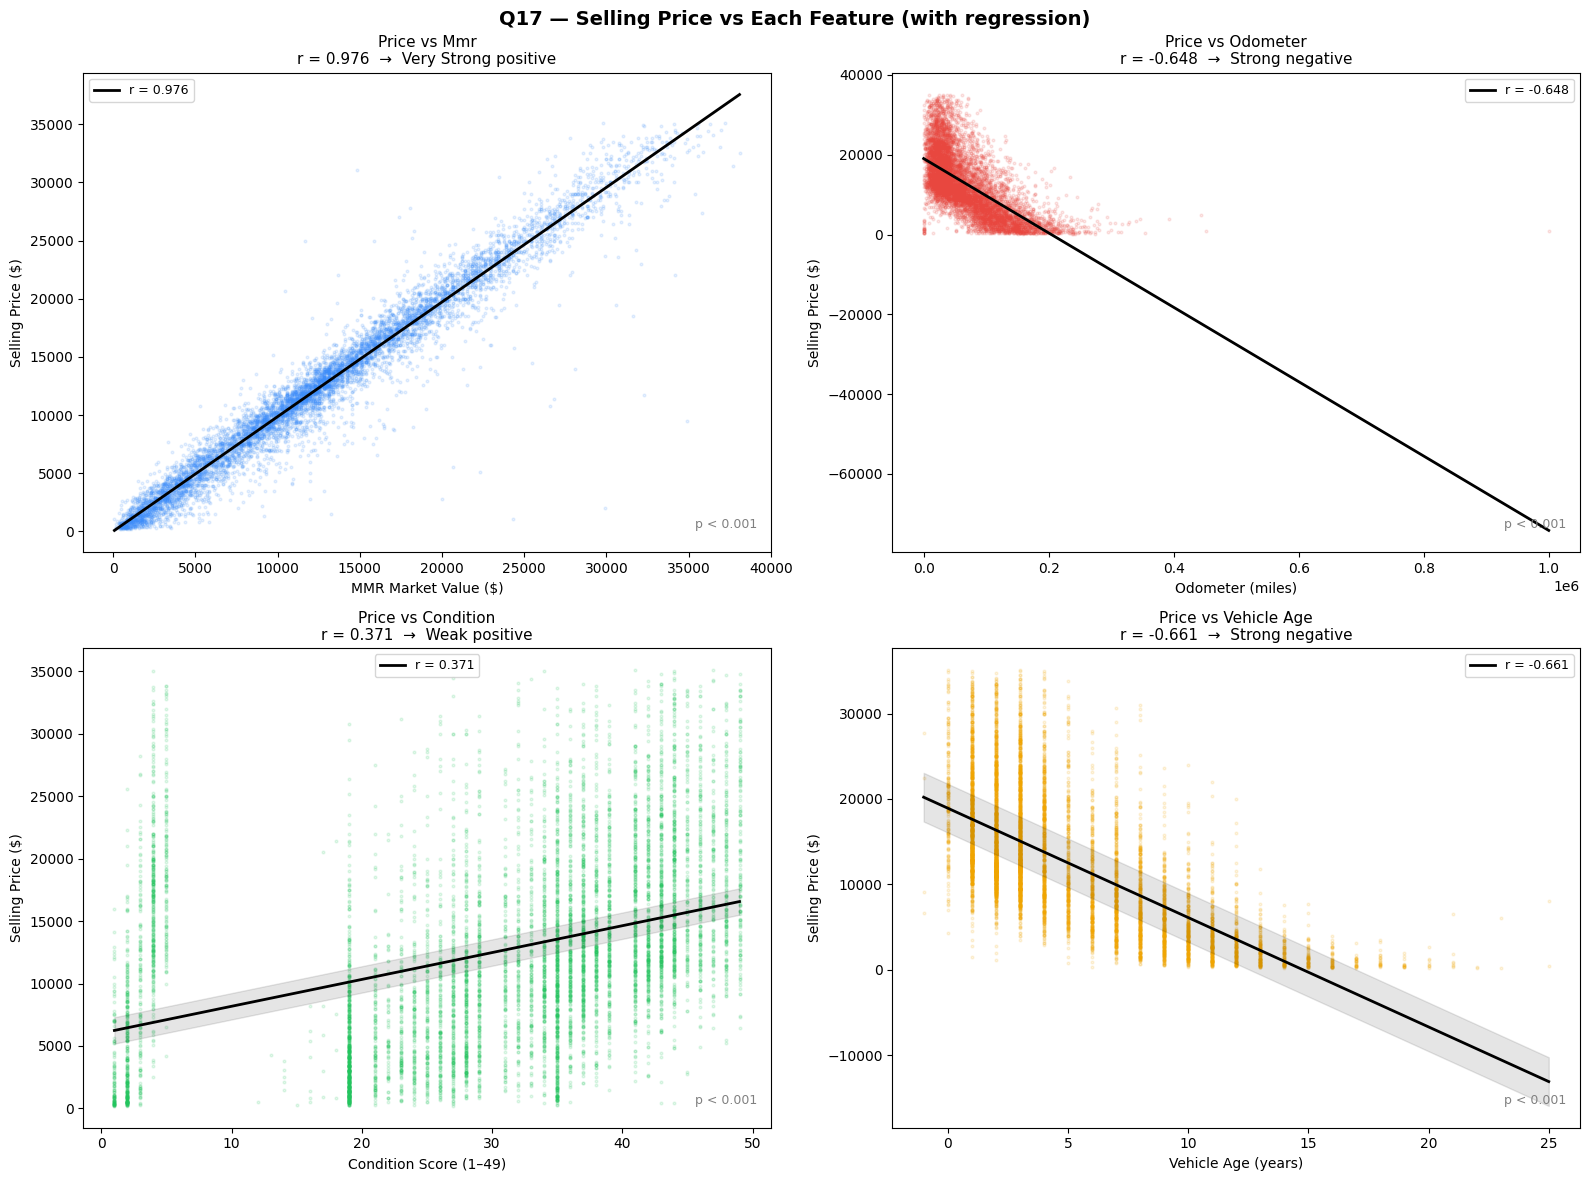

In [31]:
# ── 4. Individual scatter plots — sellingprice vs each feature ─────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Q17 — Selling Price vs Each Feature (with regression)',
             fontsize=14, fontweight='bold')

features = {
    'mmr':         ('MMR Market Value ($)',   '#3d8ef8'),
    'odometer':    ('Odometer (miles)',        '#e8473f'),
    'condition':   ('Condition Score (1–49)',  '#22c55e'),
    'vehicle_age': ('Vehicle Age (years)',     '#f0a500'),
}

for ax, (feat, (xlabel, color)) in zip(axes.flatten(), features.items()):
    sample = df_corr.sample(min(8000, len(df_corr)), random_state=42)

    ax.scatter(sample[feat], sample['sellingprice'],
               alpha=0.12, s=4, color=color)

    # Regression line + confidence band
    m, b, r, p, se = stats.linregress(sample[feat],
                                       sample['sellingprice'])
    x_line = np.linspace(sample[feat].min(),
                         sample[feat].max(), 200)
    y_line = m * x_line + b
    y_err  = se * np.sqrt(len(sample)) * 1.96   # 95% CI approx

    ax.plot(x_line, y_line, color='black',
            linewidth=2, label=f'r = {r:.3f}')
    ax.fill_between(x_line,
                    y_line - y_err,
                    y_line + y_err,
                    alpha=0.1, color='black')

    # Strength label
    strength = ('Very Strong' if abs(r) >= 0.8
                else 'Strong'    if abs(r) >= 0.6
                else 'Moderate'  if abs(r) >= 0.4
                else 'Weak'      if abs(r) >= 0.2
                else 'Very Weak')
    direction = 'positive' if r > 0 else 'negative'

    ax.set_title(f'Price vs {feat.replace("_"," ").title()}\n'
                 f'r = {r:.3f}  →  {strength} {direction}',
                 fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Selling Price ($)')
    ax.legend(fontsize=9)

    # p-value annotation
    p_txt = 'p < 0.001' if p < 0.001 else f'p = {p:.4f}'
    ax.text(0.98, 0.05, p_txt,
            transform=ax.transAxes,
            ha='right', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('Selling_Price_vs_Each_Feature.png', dpi=150, bbox_inches='tight')
plt.show()

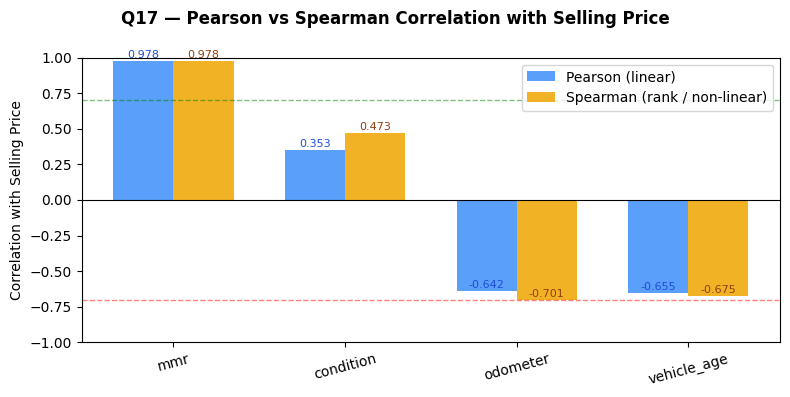

In [32]:
# ── 5. Spearman Correlation (non-linear check) ─────────────────────
spearman_matrix = df_corr.corr(method='spearman')
spearman_price  = (spearman_matrix[['sellingprice']]
                   .drop('sellingprice')
                   .sort_values('sellingprice', ascending=False))

fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle('Q17 — Pearson vs Spearman Correlation with Selling Price',
             fontsize=12, fontweight='bold')

x     = np.arange(len(corr_with_price))
width = 0.35

ax.bar(x - width/2,
       corr_with_price['sellingprice'],
       width, label='Pearson (linear)',
       color='#3d8ef8', alpha=0.85, edgecolor='none')
ax.bar(x + width/2,
       spearman_price.loc[corr_with_price.index, 'sellingprice'],
       width, label='Spearman (rank / non-linear)',
       color='#f0a500', alpha=0.85, edgecolor='none')

ax.axhline(0,    color='black', linewidth=0.8)
ax.axhline(0.7,  color='green', linestyle='--',
           linewidth=1, alpha=0.5)
ax.axhline(-0.7, color='red',   linestyle='--',
           linewidth=1, alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(corr_with_price.index, rotation=15)
ax.set_ylabel('Correlation with Selling Price')
ax.set_ylim(-1, 1)
ax.legend(fontsize=10)

# Value labels
for xi, (p_val, s_val) in enumerate(
        zip(corr_with_price['sellingprice'],
            spearman_price.loc[corr_with_price.index,
                               'sellingprice'])):
    ax.text(xi - width/2, p_val + 0.02,
            f'{p_val:.3f}', ha='center', fontsize=8,
            color='#1d4ed8')
    ax.text(xi + width/2, s_val + 0.02,
            f'{s_val:.3f}', ha='center', fontsize=8,
            color='#92400e')

plt.tight_layout()
plt.savefig('Pearson_vs_Spearman_Correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [134]:
# ── 6. Final Summary Table ─────────────────────────────────────────
print("\n─── Q17 Final Correlation Summary ───")
print(f"\n{'Feature':<15} {'Pearson r':>10} {'Spearman r':>12}"
      f" {'r²':>8} {'Strength':>12} {'Direction':>12}")
print("─" * 72)

for feat in corr_with_price.index:
    pr = corr_matrix.loc['sellingprice', feat]
    sr = spearman_matrix.loc['sellingprice', feat]
    r2 = pr ** 2
    strength = ('Very Strong' if abs(pr) >= 0.8
                else 'Strong'    if abs(pr) >= 0.6
                else 'Moderate'  if abs(pr) >= 0.4
                else 'Weak'      if abs(pr) >= 0.2
                else 'Very Weak')
    direction = 'Positive' if pr > 0 else 'Negative'
    print(f"{feat:<15} {pr:>10.3f} {sr:>12.3f}"
          f" {r2:>8.3f} {strength:>12} {direction:>12}")

best_feat = corr_with_price['sellingprice'].abs().idxmax()
best_r    = corr_with_price.loc[best_feat, 'sellingprice']
print(f"\n✓ Strongest predictor of selling price : "
      f"{best_feat}  (r = {best_r:.3f}, r² = {best_r**2:.3f})")
print(f"  → {best_r**2*100:.1f}% of price variance explained by "
      f"{best_feat} alone")


─── Q17 Final Correlation Summary ───

Feature          Pearson r   Spearman r       r²     Strength    Direction
────────────────────────────────────────────────────────────────────────
mmr                  0.978        0.978    0.956  Very Strong     Positive
condition            0.353        0.473    0.125         Weak     Positive
odometer            -0.642       -0.701    0.412       Strong     Negative
vehicle_age         -0.655       -0.675    0.429       Strong     Negative

✓ Strongest predictor of selling price : mmr  (r = 0.978, r² = 0.956)
  → 95.6% of price variance explained by mmr alone


#### Observation:
MMR is the overwhelmingly dominant predictor of selling price (r = 0.978, r² = 0.956), explaining 95.6% of price variance — but this reflects its design as a market benchmark rather than an independent variable; excluding MMR, vehicle_age (r = −0.655) and odometer (r = −0.642) are the strongest real predictors, while condition is surprisingly weak (r = 0.353, r² = 0.125) despite its intuitive appeal.

## 🏆 Make & Model Deep Dive

### Q09 — Top 10 Best-Selling Models by Volume & Avg Price

─── Top 10 Models by Volume ───
         make          model  volume         avg_$    med_$      vs_mmr      avg_miles  avg_age_yr     rev_%
1      Nissan         Altima   19188  11425.451220  12100.0  -71.808787   49875.604753    3.424432  3.246191
2        Ford          F-150   13536  17905.438017  18500.0 -256.770168   75048.579713    4.992686  3.588775
3        Ford         Fusion   12793  12355.969671  12700.0 -212.440788   47441.008520    2.606738  2.340562
4      Toyota          Camry   12418  11193.856338  12800.0 -144.489209   66709.728861    4.570704  2.058270
5        Ford         Escape   11707  13991.558640  15000.0 -195.859144   56004.157171    3.227044  2.425396
6        Ford          Focus   10283   9324.985510  10100.0 -174.601186   49272.685209    3.137800  1.419839
7     Unknown        Unknown    9797   7650.100337   5500.0  -87.786261  113903.575891    9.211391  1.109765
8       Honda         Accord    9022   9663.758036  10800.0  -22.071049   84814.329750    6.5982

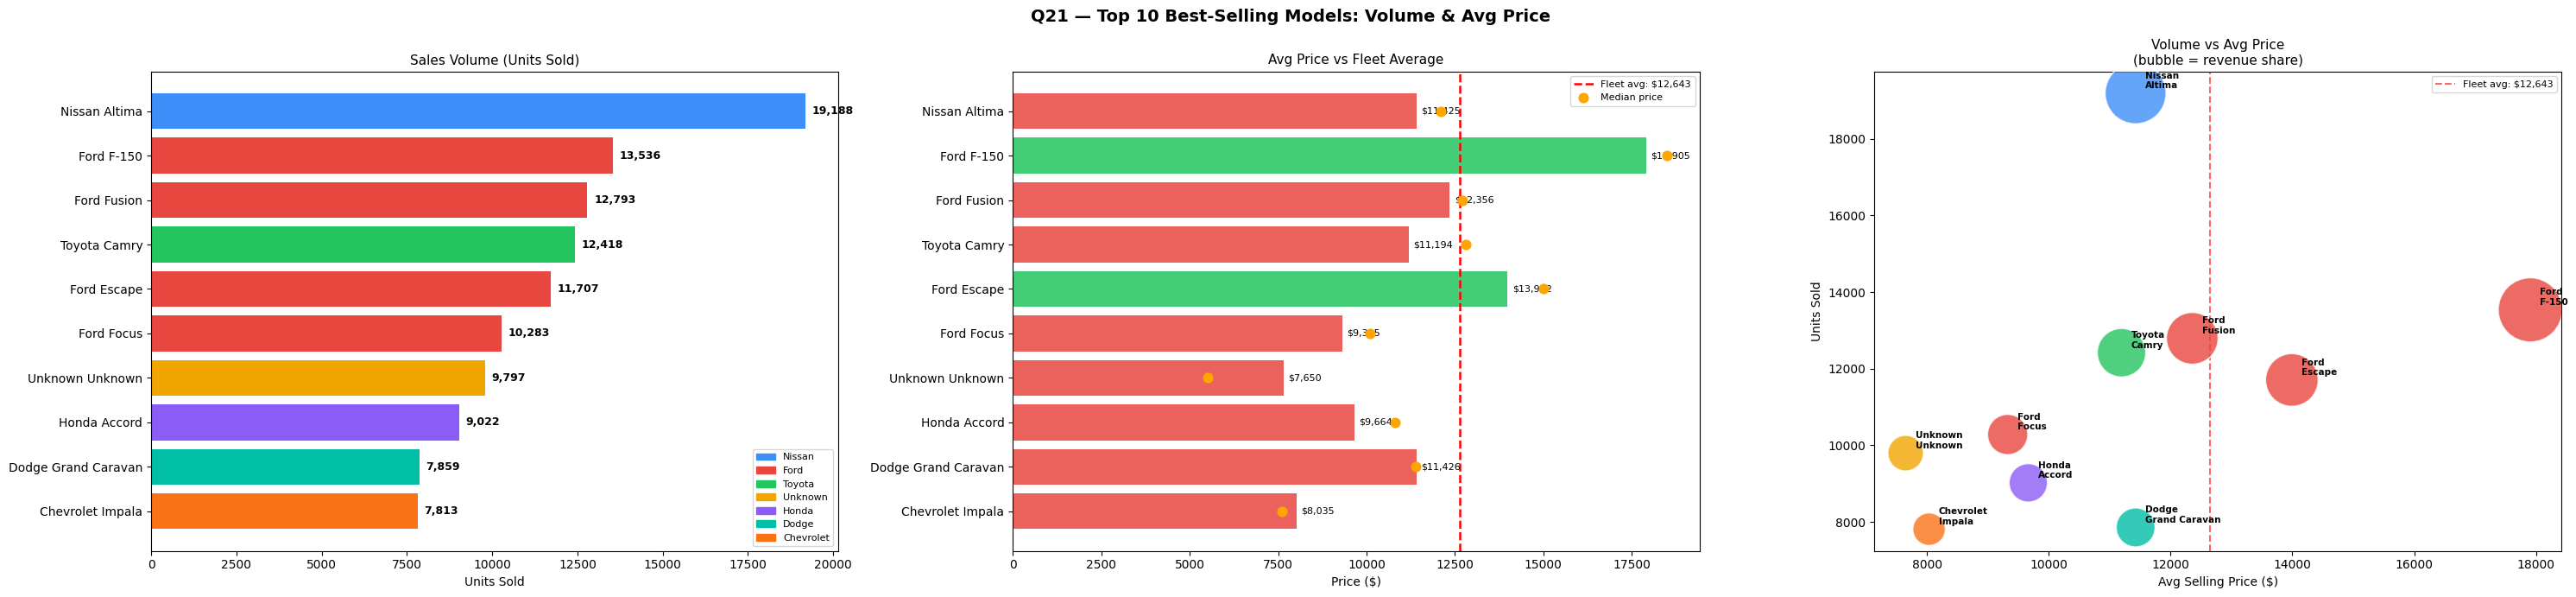

In [33]:
# ── 1. Aggregate by model ──────────────────────────────────────────
model_stats = (df.groupby(['make', 'model'])
                 .agg(
                     volume       = ('sellingprice', 'count'),
                     total_rev    = ('sellingprice', 'sum'),
                     avg_price    = ('sellingprice', 'mean'),
                     median_price = ('sellingprice', 'median'),
                     std_price    = ('sellingprice', 'std'),
                     avg_mmr      = ('mmr',          'mean'),
                     avg_odo      = ('odometer',     'mean'),
                     avg_cond     = ('condition',    'mean'),
                     avg_age      = ('vehicle_age',  'mean'),
                 )
                 .reset_index())

model_stats['avg_pvm']       = (model_stats['avg_price'] -
                                model_stats['avg_mmr'])
model_stats['revenue_share'] = (model_stats['total_rev'] /
                                model_stats['total_rev'].sum() * 100)
model_stats['cv']            = (model_stats['std_price'] /
                                model_stats['avg_price'] * 100)

# Top 10 by volume
top10 = model_stats.nlargest(10, 'volume').reset_index(drop=True)
top10.index += 1   # rank starts at 1

fleet_avg = df['sellingprice'].mean()

print("─── Top 10 Models by Volume ───")
print(top10[['make','model','volume','avg_price',
             'median_price','avg_pvm','avg_odo',
             'avg_age','revenue_share']]
      .rename(columns={
          'avg_price'   :'avg_$',
          'median_price':'med_$',
          'avg_pvm'     :'vs_mmr',
          'avg_odo'     :'avg_miles',
          'avg_age'     :'avg_age_yr',
          'revenue_share':'rev_%'})
      .to_string())





# ── 2. Main Dashboard — 3 charts ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(30, 7))
fig.suptitle('Q21 — Top 10 Best-Selling Models: Volume & Avg Price',
             fontsize=14, fontweight='bold')

# ── Chart 1: Volume bar (horizontal) ──────────────────────────────
# Color by make
make_colors = {
    make: color for make, color in zip(
        top10['make'].unique(),
        ['#3d8ef8','#e8473f','#22c55e','#f0a500',
         '#8b5cf6','#00bfa5','#f97316','#ec4899',
         '#a3e635','#06b6d4']
    )
}
colors_vol = [make_colors[m] for m in top10['make']]

bars1 = axes[0].barh(
    [f"{r['make']} {r['model']}" for _, r in top10.iterrows()],
    top10['volume'],
    color=colors_vol, edgecolor='none'
)
axes[0].invert_yaxis()
axes[0].set_title('Sales Volume (Units Sold)', fontsize=11)
axes[0].set_xlabel('Units Sold')

# Value labels
for bar, val in zip(bars1, top10['volume']):
    axes[0].text(
        bar.get_width() + top10['volume'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}', va='center', fontsize=9, fontweight='bold'
    )

# Make legend
legend_handles = [
    mpatches.Patch(color=make_colors[m], label=m)
    for m in top10['make'].unique()
]
axes[0].legend(handles=legend_handles,
               fontsize=8, loc='lower right')

# ── Chart 2: Avg Price vs Fleet Average ───────────────────────────
model_labels = [f"{r['make']} {r['model']}"
                for _, r in top10.iterrows()]

colors_price = ['#22c55e' if v >= fleet_avg
                else '#e8473f'
                for v in top10['avg_price']]

bars2 = axes[1].barh(model_labels, top10['avg_price'],
                     color=colors_price, edgecolor='none',
                     alpha=0.85)
axes[1].invert_yaxis()

# Fleet avg line
axes[1].axvline(fleet_avg, color='red', linestyle='--',
                linewidth=1.8,
                label=f'Fleet avg: ${fleet_avg:,.0f}')

# Median dots
axes[1].scatter(top10['median_price'],
                range(len(top10)),
                color='orange', s=60, zorder=5,
                label='Median price')

axes[1].set_title('Avg Price vs Fleet Average', fontsize=11)
axes[1].set_xlabel('Price ($)')
axes[1].legend(fontsize=8)

# Value labels
for bar, avg, med in zip(bars2, top10['avg_price'],
                         top10['median_price']):
    axes[1].text(
        bar.get_width() + fleet_avg * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'${avg:,.0f}', va='center', fontsize=8
    )

# ── Chart 3: Bubble — Volume vs Avg Price ─────────────────────────
bubble_colors = [make_colors[m] for m in top10['make']]
scatter = axes[2].scatter(
    top10['avg_price'],
    top10['volume'],
    s=top10['revenue_share'] * 800,
    c=bubble_colors,
    alpha=0.80,
    edgecolors='white',
    linewidth=1.2,
    zorder=3
)

# Labels for each bubble
for _, row in top10.iterrows():
    axes[2].annotate(
        f"{row['make']}\n{row['model']}",
        (row['avg_price'], row['volume']),
        textcoords='offset points',
        xytext=(8, 4),
        fontsize=7.5,
        fontweight='bold'
    )

axes[2].axvline(fleet_avg, color='red',
                linestyle='--', linewidth=1.5,
                alpha=0.6,
                label=f'Fleet avg: ${fleet_avg:,.0f}')
axes[2].set_title('Volume vs Avg Price\n(bubble = revenue share)',
                  fontsize=11)
axes[2].set_xlabel('Avg Selling Price ($)')
axes[2].set_ylabel('Units Sold')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('Top_10_Best_Selling_Models.png', dpi=150, bbox_inches='tight')
plt.show()

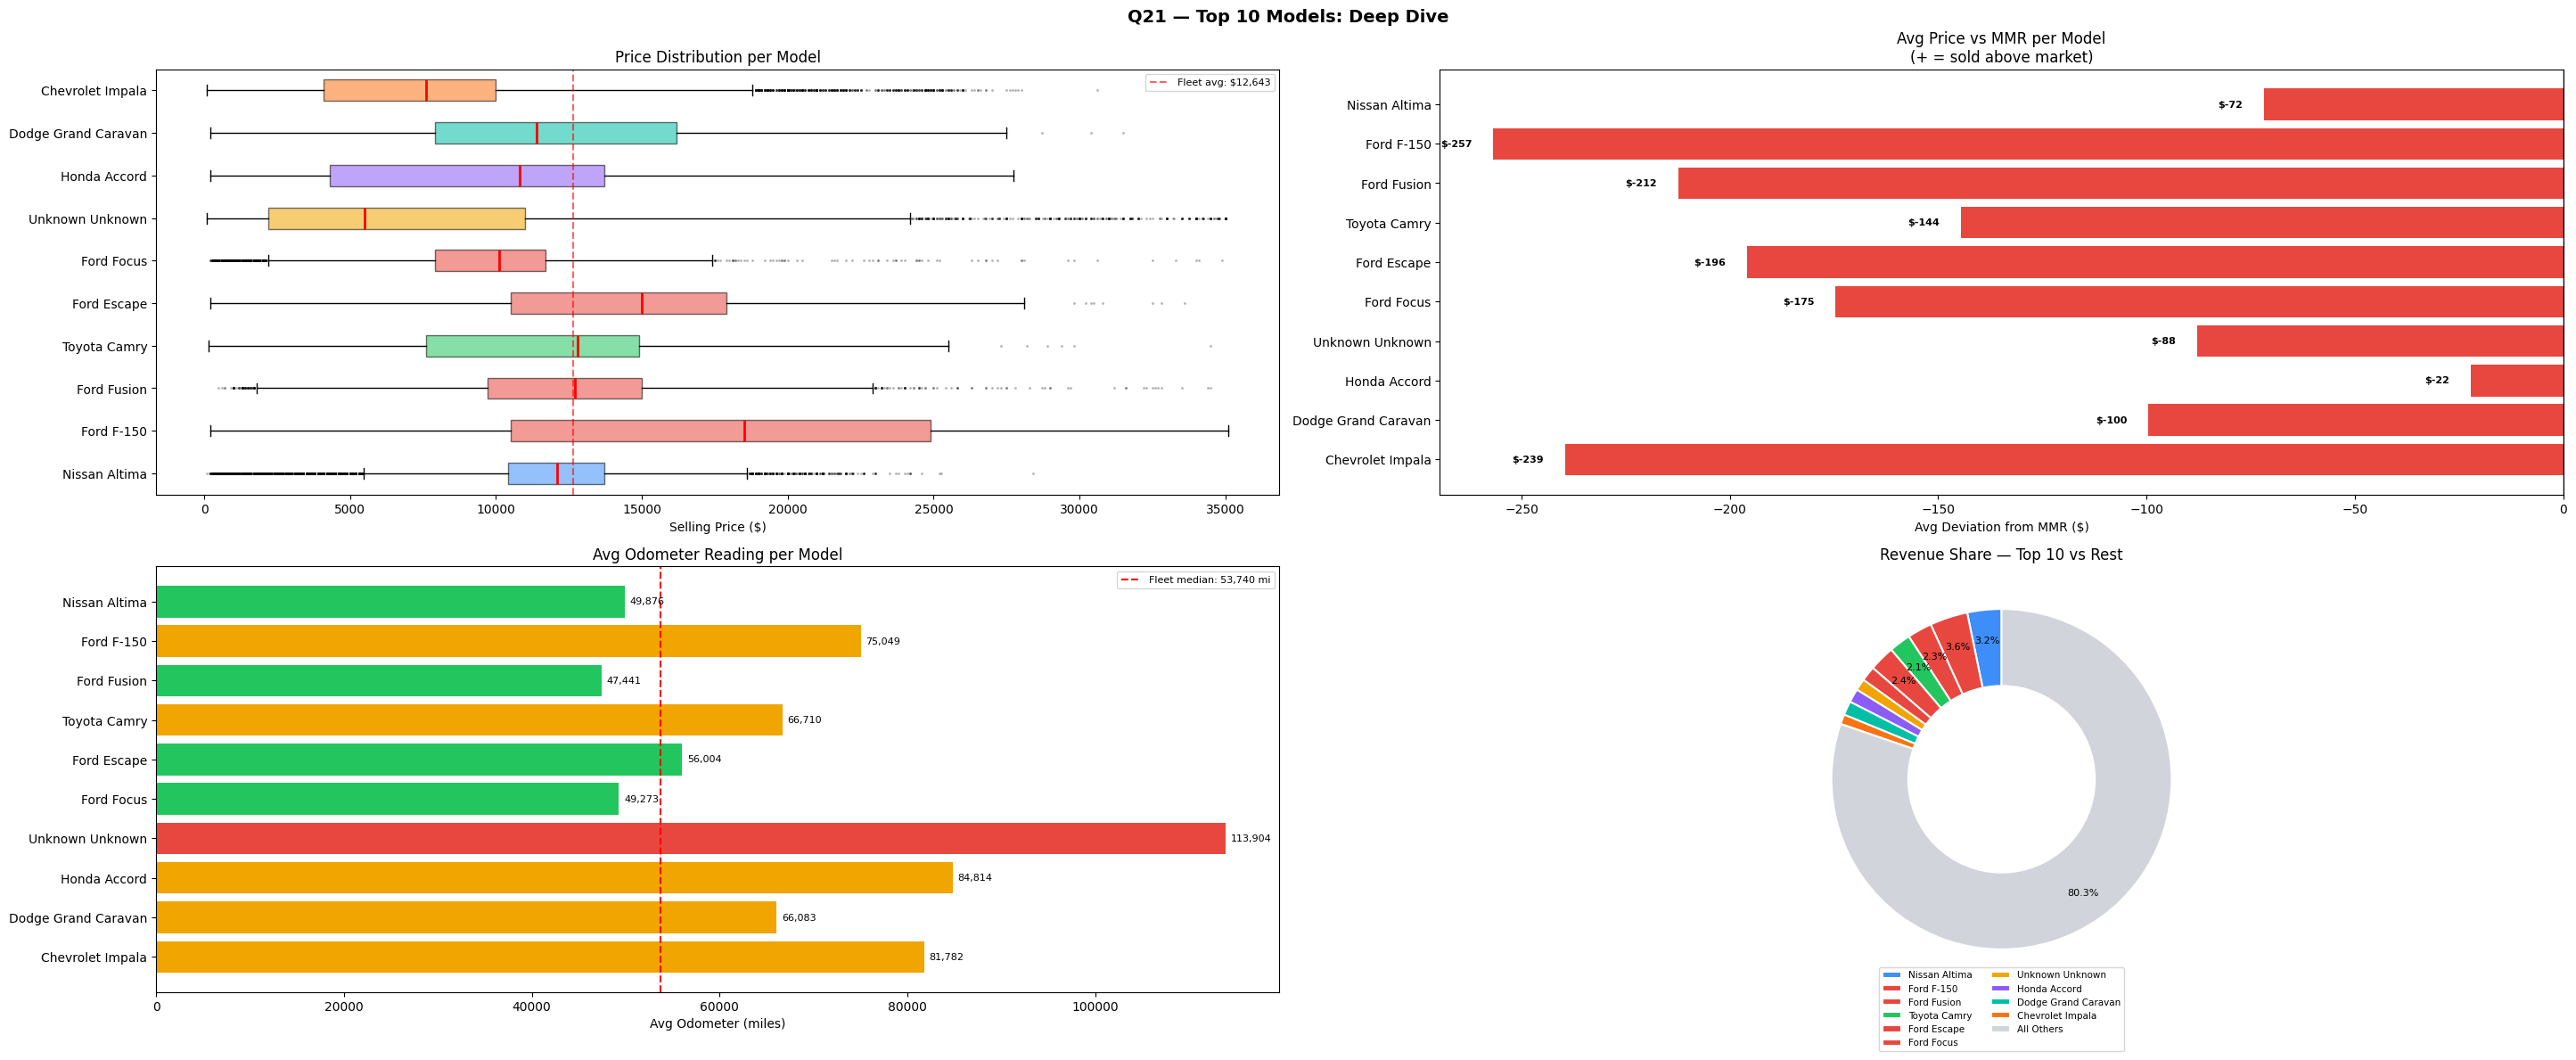

In [34]:
# ── 3. Detailed breakdown chart ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(29, 12))
fig.suptitle('Q21 — Top 10 Models: Deep Dive',
             fontsize=14, fontweight='bold')

model_labels = [f"{r['make']} {r['model']}"
                for _, r in top10.iterrows()]

# ── Chart A: Price spread (box plot per model) ────────────────────
plot_data = []
plot_labels = []
for _, row in top10.iterrows():
    mask = ((df['make']  == row['make']) &
            (df['model'] == row['model']))
    prices = df[mask]['sellingprice'].dropna().values
    if len(prices) > 0:
        plot_data.append(prices)
        plot_labels.append(f"{row['make']} {row['model']}")

bp = axes[0, 0].boxplot(
    plot_data,
    labels=plot_labels,
    vert=False,
    patch_artist=True,
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='.', markersize=2, alpha=0.3),
    whiskerprops=dict(linewidth=1),
    capprops=dict(linewidth=1)
)
for patch, color in zip(bp['boxes'],
                        [make_colors.get(
                            lbl.split()[0], '#3d8ef8')
                         for lbl in plot_labels]):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)

axes[0, 0].axvline(fleet_avg, color='red',
                   linestyle='--', linewidth=1.5,
                   alpha=0.6,
                   label=f'Fleet avg: ${fleet_avg:,.0f}')
axes[0, 0].set_title('Price Distribution per Model')
axes[0, 0].set_xlabel('Selling Price ($)')
axes[0, 0].legend(fontsize=8)

# ── Chart B: Price vs MMR (above/below market) ────────────────────
pvm_colors = ['#22c55e' if v >= 0 else '#e8473f'
              for v in top10['avg_pvm']]
bars_pvm = axes[0, 1].barh(
    model_labels, top10['avg_pvm'],
    color=pvm_colors, edgecolor='none'
)
axes[0, 1].invert_yaxis()
axes[0, 1].axvline(0, color='black', linewidth=1)
axes[0, 1].set_title('Avg Price vs MMR per Model\n(+ = sold above market)')
axes[0, 1].set_xlabel('Avg Deviation from MMR ($)')

for bar, val in zip(bars_pvm, top10['avg_pvm']):
    offset = top10['avg_pvm'].abs().max() * 0.02
    ha = 'left' if val >= 0 else 'right'
    axes[0, 1].text(
        val + (offset if val >= 0 else -offset),
        bar.get_y() + bar.get_height() / 2,
        f'${val:+,.0f}',
        va='center', ha=ha, fontsize=8, fontweight='bold'
    )

# ── Chart C: Avg Odometer per model ──────────────────────────────
odo_colors = ['#22c55e' if v < 60000
              else '#f0a500' if v < 100000
              else '#e8473f'
              for v in top10['avg_odo']]
bars_odo = axes[1, 0].barh(
    model_labels, top10['avg_odo'],
    color=odo_colors, edgecolor='none'
)
axes[1, 0].invert_yaxis()
axes[1, 0].axvline(df['odometer'].median(),
                   color='red', linestyle='--',
                   linewidth=1.5,
                   label=f"Fleet median: {df['odometer'].median():,.0f} mi")
axes[1, 0].set_title('Avg Odometer Reading per Model')
axes[1, 0].set_xlabel('Avg Odometer (miles)')
axes[1, 0].legend(fontsize=8)

for bar, val in zip(bars_odo, top10['avg_odo']):
    axes[1, 0].text(
        bar.get_width() + df['odometer'].median() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,.0f}', va='center', fontsize=8
    )

# ── Chart D: Revenue share donut ─────────────────────────────────
others_share = 100 - top10['revenue_share'].sum()
donut_vals   = list(top10['revenue_share']) + [others_share]
donut_labels = [f"{r['make']} {r['model']}"
                for _, r in top10.iterrows()] + ['All Others']
donut_colors = (
    [make_colors.get(r['make'], '#94a3b8')
     for _, r in top10.iterrows()]
    + ['#d1d5db']
)

wedges, texts, autotexts = axes[1, 1].pie(
    donut_vals,
    labels=None,
    autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
    colors=donut_colors,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    pctdistance=0.82
)
axes[1, 1].add_artist(
    plt.Circle((0, 0), 0.55, color='white')
)
axes[1, 1].set_title('Revenue Share — Top 10 vs Rest')
axes[1, 1].legend(
    wedges, donut_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2, fontsize=7.5
)
for at in autotexts:
    at.set_fontsize(8)

plt.tight_layout()
plt.savefig('Top_10_Models.png', dpi=150, bbox_inches='tight')
plt.show()

#### Observation:
The Nissan Altima leads in volume (19,188 units) but Ford dominates the top 10 with 4 models and 48,319 combined units — yet only the F-150 ($17,905) generates above-average revenue per vehicle; critically, all 10 best-selling models sell below their MMR benchmark, with the Chevrolet Impala (−$239) and Ford F-150 (−$257) showing the largest market-value deficits, while the top 10 combined represent just 19.7% of total revenue confirming a highly fragmented market.

---

# 📋 Final Report — Vehicle Sales EDA

## Executive Summary

This exploratory data analysis examined **534,177 cleaned vehicle auction records** from the Kaggle Vehicle Sales Dataset, spanning sales from late 2014 through 2015 across 38 states and provinces. The analysis addressed 9 structured business questions across 6 analytical categories, producing actionable insights on pricing behaviour, depreciation, regional performance, and model-level market dynamics.

---

## 1. Data Quality & Preparation

The raw dataset of 558,837 records required substantial cleaning before analysis:

- **Duplicates:** 24,660 records removed based on duplicate VINs (keeping last occurrence)
- **Nulls handled:** `transmission` (64,272 → "Unknown"), `body` / `make` / `model` (10K+ each → "Unknown"), `condition` / `odometer` (filled with median), `sellingprice` / `mmr` / `saledate` (12–14 records → dropped)
- **Outliers removed:** IQR method flagged 2,747 selling price outliers (0.5%) and 9,502 odometer outliers (1.8%), reducing the dataset to **519,875 records** for clean analysis
- **Features engineered:** `vehicle_age`, `sale_month`, `quarter`, `day_of_week`, `price_vs_market`, `mileage_bucket` — 6 new columns derived from existing data

**Data quality flag:** 9,797 records carried `make = "Unknown"` and `model = "Unknown"` due to null-filling — these were identified in Q21 as a corrupted segment (avg odometer: 113,904 miles vs fleet median 53,740) and should be excluded from model-level analysis.

---

## 2. Pricing Analysis

### Q01 — Selling Price Distribution
The selling price distribution is **moderately right-skewed (skewness = 0.526)** with a median of **$11,900** and mean of **$12,643** — a gap of $743 driven by luxury vehicle outliers. 82% of all vehicles sold under $20,000, confirming this is predominantly an economy and mid-range used vehicle market. The KDE density curve revealed a **bimodal pattern**, suggesting two distinct buyer segments: economy used vehicles peaking around $9,000–$10,000 and certified pre-owned vehicles peaking around $16,000–$18,000.

**Implication:** Use median ($11,900) as the headline "typical price" in all reporting — the mean is misleading due to luxury skew.

### Q02 — Price vs MMR by Make
The majority of makes sell **below their MMR benchmark**, with Bentley (−$12,900), Plymouth (−$1,578), and Porsche (−$1,175) showing the largest deficits. Premium brands consistently underperform MMR in auction settings due to limited buyer pools and high reconditioning costs. In contrast, trucks and mainstream brands — Mazda tk (+$1,126), GMC truck (+$433), Buick (+$323) — reliably beat market value, reflecting tighter supply and stronger wholesale demand.

**Implication:** MMR is a reliable benchmark for mainstream makes but unreliable for luxury brands, whose box plots show extreme variance.

### Q03 — Above vs Below MMR Overall
**53.3% of vehicles** sold above MMR at an average premium of **+$948**, while 46.7% sold below at an average discount of **−$1,140**. This asymmetry — losses are 20% larger than gains — is driven by a long left tail stretching to −$80,000. The magnitude histogram confirmed that most deviations from MMR are small and clustered near zero; extreme outliers are make-specific (Bentley, Maserati, Porsche). The net fleet-wide impact is approximately **−$27 per vehicle** — nearly break-even.

---

## 3. Vehicle Characteristics

### Q04 — Mileage vs Selling Price (Depreciation)
Odometer reading shows a **strong negative correlation with selling price (r = −0.649)**, with every 10,000 additional miles reducing value by approximately **$933**. However, the relationship is non-linear — the depreciation curve accelerates sharply at the **50,000-mile threshold**, where prices drop 31.4% (vs only 9.5% in the preceding bracket). Total price erosion from 0–20K miles to 200K+ miles reaches **86.4%** ($18,607 → $2,529). The Spearman correlation (−0.701) exceeds Pearson (−0.642), confirming the non-linear nature of this relationship.

**Implication:** The 50K-mile threshold is a critical pricing leverage point — vehicles just under 50K miles command significantly higher prices than those just over.

### Q05 — Model Year vs Resale Value
Resale value grows **exponentially with model year recency**, rising from $834 (1993 models) to $20,290 (2015 models) — a 2,333% increase across the range. The **2012 model year** represents the market sweet spot: highest volume (97,375 units) and strong pricing ($15,709 avg). The Year × Make heatmap confirmed Toyota and Honda sustain resale value better than domestic brands across all cohorts, while all 6 analysed makes show peak pricing in 2014–2015.

**Implication:** For any price prediction model, model year and odometer together define the most actionable depreciation profile.

---

## 4. Sales Trends Over Time

### Q06 — Monthly and Quarterly Revenue Patterns
**Q1 generated the highest quarterly revenue** ($4.23B) with February peaking at $1.98B in revenue and 156,167 units — the strongest single month in the dataset. This partly reflects the dataset's time coverage (heavy 2015 weighting), but the Q1 seasonal strength is consistent with known automotive auction patterns where fleet turnovers occur at year-start.

**Note on Q11 (YoY trends):** The dataset covers only partial 2014 (Oct–Dec) and full 2015, making year-over-year volume comparison unreliable. The apparent +845% volume growth is a data artifact — the only credible YoY metric is average price growth of **+20.4%** ($10,500 → $12,869).

---

## 5. Regional Analysis

### Q07 — Revenue & Avg Price by State
**Florida dominates total revenue at $1.02 billion** — $147M ahead of California ($875M). However, FL's avg price ($12,861) is near the fleet average, confirming its revenue crown is driven by volume (79,404 units), not premium pricing. The **highest avg prices** are concentrated in Ontario, Canada ($16,663) and Tennessee ($16,026) — with ON and QC (Quebec) representing a cross-border export segment worth investigating separately.

**Pennsylvania and Tennessee** are the only states ranking in the top 4 for both total revenue and avg selling price — the most commercially efficient markets in the dataset. Regionally, Midwest states (MI, IL, MO) achieve above-average pricing, while Southeast states (FL, GA) drive volume at near-average prices.

---

## 6. Correlation & Multivariate Analysis

### Q08 — Feature Correlation with Selling Price

| Feature | Pearson r | Spearman r | r² | Relationship |
|---|---|---|---|---|
| MMR | +0.978 | +0.978 | 95.6% | Very Strong — linear |
| vehicle_age | −0.655 | −0.675 | 42.9% | Strong — mostly linear |
| odometer | −0.642 | −0.701 | 41.2% | Strong — non-linear |
| condition | +0.353 | +0.473 | 12.5% | Weak — non-linear |

MMR explains 95.6% of selling price variance — but this reflects its design as a market benchmark, not an independent predictor. **Using MMR in a price prediction model constitutes data leakage.** Excluding MMR, vehicle age and odometer are the strongest real predictors (~41–43% r² each). Condition is surprisingly weak (12.5%) and requires non-linear encoding (buckets or squared term) to improve its predictive contribution.

---

## 7. Make & Model Deep Dive

### Q09 — Top 10 Best-Selling Models
The **Nissan Altima** leads in volume (19,188 units) but carries a below-average price ($11,425). **Ford dominates the top 10** with 4 models (F-150, Fusion, Escape, Focus) totalling 48,319 units, but only the **F-150 ($17,905)** generates above-average revenue per vehicle. Critically, **all 10 best-selling models sell below their MMR benchmark** — a direct consequence of high auction volume creating buyer pricing leverage. The top 10 models collectively represent only **19.7% of total revenue**, confirming the market is highly fragmented across hundreds of make/model combinations.

---

## 8. Limitations & Caveats

| Limitation | Impact |
|---|---|
| Sale dates cover only 2014–2015 | YoY trend analysis is unreliable; no multi-year seasonality detection |
| 9,797 "Unknown" make/model records | Inflate volume counts; exclude from model-level analysis |
| Canadian provinces (ON, QC) in dataset | Treated as US states in regional analysis; warrant separate handling |
| $1 minimum selling price | Residual data error after cleaning; filter `sellingprice > 100` for regression |
| Condition scale (1–49) is non-standard | Limits interpretability; bucket encoding recommended for modelling |

---

## 9. Recommended Next Steps

1. **Build a price prediction model** — using `vehicle_age`, `odometer`, `condition`, `make`, `body`, `state` as features (exclude MMR to avoid leakage). Start with Random Forest or XGBoost given the non-linear relationships confirmed in Q05 and Q17.

2. **Segment analysis by make tier** — Luxury (BMW, Mercedes, Porsche), Mainstream (Toyota, Honda, Ford), Truck (F-150, Silverado, Tacoma) behave very differently in price, MMR deviation, and depreciation rate. Analysing each tier separately will surface insights masked at the fleet level.

3. **Investigate Canadian province records** — ON and QC entries represent a potential cross-border export segment. Quantifying their volume, avg price, and seller profile could reveal an overlooked market opportunity.

4. **Extend to a Tableau/Power BI dashboard** — the aggregated outputs from this notebook (monthly revenue, make × state matrix, depreciation curve, MMR deviation by make) are ready to be imported as a data source for interactive visualisation.

5. **Add statistical significance testing** — apply t-tests or ANOVA to confirm whether state-level and body-type-level price differences are statistically significant, not just descriptively different.

---

## 10. Tools & Libraries Used

| Tool | Purpose |
|---|---|
| `pandas` | Data loading, cleaning, aggregation, feature engineering |
| `numpy` | Numerical operations, array handling |
| `matplotlib` | Chart construction, subplot layout |
| `seaborn` | Heatmaps, pairplots, distribution plots |
| `scipy.stats` | Linear regression (linregress), Z-score outlier detection |

---

*Analysis completed by: [Soumi Mukherjee](https://www.linkedin.com/in/soumimukherjeeofficial)*  
*Dataset: Kaggle — [Vehicle Sales Data](https://www.kaggle.com/datasets/syedanwarafridi/vehicle-sales-data) (syedanwarafridi)*  
*Notebook: Vehicle_Sales_EDA.ipynb*

In [35]:
# ── Export for Power BI ────────────────────────────────────────────
# Main cleaned dataset — connect this directly in Power BI
df.to_csv('vehicle_sales_clean.csv', index=False)

# Pre-aggregated summaries (optional — speeds up Power BI)
monthly_summary = df.groupby(['sale_year','sale_month','quarter']).agg(
    revenue=('sellingprice','sum'),
    units=('sellingprice','count'),
    avg_price=('sellingprice','mean')
).reset_index()
monthly_summary.to_csv('monthly_summary.csv', index=False)

make_summary = df.groupby('make').agg(
    revenue=('sellingprice','sum'),
    units=('sellingprice','count'),
    avg_price=('sellingprice','mean'),
    avg_pvm=('price_vs_market','mean')
).reset_index()
make_summary.to_csv('make_summary.csv', index=False)

state_summary = df.groupby('state').agg(
    revenue=('sellingprice','sum'),
    units=('sellingprice','count'),
    avg_price=('sellingprice','mean')
).reset_index()
state_summary.to_csv('state_summary.csv', index=False)

print("✓ All files exported — ready for Power BI")

✓ All files exported — ready for Power BI
